In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
from kaggle_secrets import UserSecretsClient
from pathlib import Path
import shutil

token = UserSecretsClient().get_secret("GITHUB_TOKEN")
repo = Path("Smart-MCQ-Solver")

!git clone -b Milestone-2 --single-branch https://{token}@github.com/mimakhdumiiitm/{repo}.git

# Remove unnecessary folders
for p in [".git", "outputs", "notebooks", "reports"]:
    shutil.rmtree(repo / p, ignore_errors=True)

# Remove all __pycache__ folders
for p in repo.rglob("__pycache__"):
    shutil.rmtree(p, ignore_errors=True)

# Remove unnecessary files
for p in [".gitignore", "README.md"]:
    (repo / p).unlink(missing_ok=True)

# Remove compiled Python files
for p in repo.rglob("*.pyc"):
    p.unlink(missing_ok=True)

print("Repository ready.")

Cloning into 'Smart-MCQ-Solver'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (251/251), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 251 (delta 103), reused 206 (delta 68), pack-reused 0 (from 0)
Receiving objects: 100% (251/251), 6.24 MiB | 17.08 MiB/s, done.
Resolving deltas: 100% (103/103), done.
Repository ready.


In [ ]:
# pull the latest code without restarting the notebook
!cd Smart-MCQ-Solver && git pull

# Milestone 1: EDA and Initial Exploration

### Overview

In this milestone, I explored the dataset end to end and built a solid foundation for the project. I started by loading and validating the training and test datasets, handling missing values, and cleaning the text to ensure consistent inputs. I then created basic text-based features, analyzed vocabulary and answer distributions, and produced visualizations to better understand the data.

To explore the relationship between prompts and answer options, I generated TF-IDF and Word2Vec embeddings, computed similarity scores, and evaluated simple ranking strategies. I also organized the entire workflow into a modular pipeline consisting of data loading, preprocessing, embedding generation, similarity analysis, evaluation, and visualization, creating a reusable foundation for future development.

---

### Objectives

- Understand the structure and quality of the dataset
- Clean and preprocess the text data
- Explore text characteristics through statistical analysis and visualizations
- Generate text embeddings for semantic representation
- Analyze similarity between prompts and answer options
- Establish an initial baseline for future model improvements
- Build a modular and reusable data processing pipeline

---

### Work Completed

#### Data Preparation
- Loaded and validated the training and test datasets
- Checked dataset structure and data quality
- Identified and handled missing text values
- Cleaned and standardized text fields
- Added text-length features for prompts and options

#### Exploratory Data Analysis (EDA)
- Visualized text length distributions
- Analyzed word frequency distributions
- Generated word clouds for prompts and answer options
- Examined answer class distribution

#### Embedding Generation
- Built TF-IDF embeddings for textual representation
- Trained and generated Word2Vec embeddings
- Visualized Word2Vec embeddings using PCA

#### Similarity Analysis
- Computed similarity scores between prompts and answer options
- Compared similarity patterns for correct and incorrect answers
- Explored semantic relationships within the dataset

#### Baseline Evaluation
- Evaluated simple ranking strategies
- Measured performance using MAP@3
- Analyzed answer rank distributions

#### Pipeline Organization
- Structured the workflow into reusable stages:
  - Data Loading
  - Preprocessing
  - Embedding Generation
  - Similarity Analysis
  - Evaluation
  - Visualization

---

### Key Outcomes

- Built a clean and reliable preprocessing pipeline.
- Gained a comprehensive understanding of the dataset through statistical analysis and visual exploration.
- Generated both TF-IDF and Word2Vec representations for semantic analysis.
- Established baseline similarity metrics and ranking performance using MAP@3.
- Created a modular workflow that can be extended with feature engineering and machine learning models in future milestones.

---

### Next Steps

The next milestone will focus on:
- Advanced feature engineering
- Model development and training
- Hyperparameter tuning
- Cross-validation
- Performance optimization
- Final prediction generation

In [ ]:
# import sys

# sys.path.append("/kaggle/working/Smart-MCQ-Solver")

# from scripts.main_eda import (
#     step_load_data,
#     step_preprocessing,
#     step_word_frequency,
#     step_answer_distribution,
#     step_tfidf,
#     step_word2vec,
#     step_similarity,
#     step_metrics,
# )

In [ ]:
# train_df, test_df = step_load_data()

In [ ]:
# train_df, test_df = step_preprocessing(train_df, test_df)

In [ ]:
# step_answer_distribution(train_df)

In [ ]:
# step_word_frequency(train_df)

In [ ]:
# # Run the modified TF-IDF step
# X_train, X_test, tfidf_embedder = step_tfidf(train_df, test_df)

# print("Train shape:", X_train.shape)
# print("Test shape :", X_test.shape)

In [ ]:
# w2v_embedder = step_word2vec(train_df)

In [ ]:
# train_df = step_similarity(train_df, tfidf_embedder, w2v_embedder)

In [ ]:
# results_df = step_metrics(train_df)

# Milestone 2: Transformer-Based Semantic Retrieval Pipeline

### Overview

In this milestone, we extended the Smart MCQ Solver by introducing a transformer-based semantic retrieval pipeline. Unlike the previous TF-IDF and Word2Vec approaches, this implementation leverages modern transformer models for semantic understanding and combines embedding similarity with Natural Language Inference (NLI) through an ensemble ranking strategy.

The pipeline is designed to be modular, reusable, GPU-aware, and easily extensible for experimentation with different transformer models and ranking strategies.

---

### Objectives

* Build a modular transformer-based inference pipeline.
* Generate semantic embeddings using Sentence Transformers (SBERT).
* Perform zero-shot answer scoring using an NLI model.
* Combine multiple scoring strategies through an ensemble ranker.
* Evaluate model performance using MAP@3.
* Generate Kaggle-compatible submission files.
* Integrate experiment tracking using Weights & Biases (W&B).
* Support automatic GPU detection with safe CPU fallback.

---

### Components Implemented

#### 1. GPU Environment Utilities

Implemented a dedicated GPU utility module to:

* Configure CUDA environment variables.
* Detect available GPU devices.
* Display GPU diagnostics.
* Verify compute capability.
* Automatically switch to CPU when GPU requirements are not satisfied.
* Support multi-GPU environments.

---

#### 2. Weights & Biases Integration

Created reusable utilities for experiment tracking by:

* Authenticating using Kaggle Secrets.
* Initializing experiment runs.
* Logging configuration parameters.
* Recording evaluation metrics.
* Logging generated submission files.
* Safely finalizing runs after execution.

---

#### 3. Transformer Model Loader

Developed safe model loading utilities for:

* Sentence Transformer (SBERT) embedding models.
* Zero-shot Natural Language Inference models.

Features include:

* Automatic device placement.
* CUDA error detection.
* CPU fallback when GPU execution fails.
* Initial inference checks to validate successful model loading.

---

#### 4. Transformer Embedding Scoring

Implemented an `EmbeddingScorer` that:

* Encodes prompts and answer options into dense vector representations.
* Generates normalized sentence embeddings.
* Computes cosine similarity between questions and candidate answers.
* Processes records efficiently using batch inference.

---

#### 5. Zero-Shot NLI Scoring

Implemented a `ZeroShotScorer` that:

* Converts each answer option into a hypothesis statement.
* Scores premise-hypothesis pairs using an NLI transformer.
* Uses entailment probabilities as semantic relevance scores.
* Supports batched inference for improved efficiency.

---

#### 6. Ensemble Ranking

Designed an ensemble ranking module capable of:

* Normalizing embedding and zero-shot scores.
* Combining scores using configurable weights.
* Supporting multiple prediction strategies:

  * Embedding only
  * Zero-shot only
  * Ensemble
* Producing Top-K ranked answer predictions.

---

#### 7. Submission Generator

Implemented a reusable submission utility that:

* Generates Kaggle submission files.
* Validates submission format.
* Ensures exactly Top-K predictions for every sample.
* Saves submission files automatically.
* Logs submission artifacts to Weights & Biases.

---

#### 8. End-to-End Pipeline

Built a complete execution pipeline consisting of the following stages:

1. GPU setup
2. W&B initialization
3. Data loading
4. Model loading
5. Smoke testing
6. Embedding scoring
7. Zero-shot scoring
8. Ensemble prediction
9. MAP@3 evaluation
10. Strategy comparison
11. Result visualization
12. Submission generation
13. Experiment finalization

---

### Key Features

* Modular project architecture
* GPU-aware execution
* Automatic CPU fallback
* Transformer-based semantic retrieval
* Batch inference for efficiency
* Ensemble ranking strategy
* MAP@3 evaluation
* Experiment tracking with W&B
* Kaggle-ready submission generation
* Reusable and extensible codebase

---

### Technologies Used

* Python
* PyTorch
* Hugging Face Transformers
* Sentence Transformers
* NumPy
* Pandas
* Weights & Biases (W&B)
* Kaggle

---

### Outcome

This milestone successfully establishes a robust transformer-based semantic retrieval framework for the Smart MCQ Solver. The system combines semantic embeddings with zero-shot inference to improve answer ranking while maintaining a clean, modular architecture that supports experimentation, evaluation, and future enhancements.


In [20]:
import sys
import time

sys.path.insert(0, "/kaggle/working/Smart-MCQ-Solver")

from scripts.main_transformer import (
    DEVICE,
    step_init_wandb,
    step_load_data,
    step_load_models,
    step_smoke_test,
    step_score,
    step_predict,
    step_evaluate,
    step_submission
)
from utils.wandb_utils import finish_wandb_run
from config.config import SUBMISSION_OUT_PATH

In [3]:
total_t0 = time.time()

print("=" * 55)
print("  TRANSFORMER MCQ PIPELINE")
print("=" * 55)

# Step 1: W&B
run = step_init_wandb()

  TRANSFORMER MCQ PIPELINE

STEP 1 : W&B INITIALIZATION


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B authenticated via Kaggle secrets


W&B run initialized : transformer-embeddings-zeroshot
Project             : 22f3001418-t22026
W&B setup complete


In [4]:
# Step 2: Data
train_data, test_data = step_load_data()


STEP 2 : DATA LOADING
Loaded  : /kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/outputs/processed_files/train_processed.csv
Shape   : (2000, 26)
Train shape : (2000, 26)
   Columns     : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'prompt_clean', 'A_clean', 'B_clean', 'C_clean', 'D_clean', 'E_clean', 'prompt_char_len', 'prompt_word_len', 'A_char_len', 'A_word_len', 'B_char_len', 'B_word_len', 'C_char_len', 'C_word_len', 'D_char_len', 'D_word_len', 'E_char_len', 'E_word_len']
   Answer dist :
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64
Processed train saved to: /kaggle/working/outputs/processed_files/train_processed.csv
Loaded  : /kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/outputs/processed_files/test_processed.csv
Shape   : (500, 25)
Test shape  : (500, 25)
Processed test saved to: /kaggle/working/outputs/processed_files/test_processed.csv

Data ready | Train: 2000 | Test: 500

Sample record:
   Pr

In [5]:
# Step 3: Models
emb_scorer, zs_scorer = step_load_models()


STEP 3 : MODEL LOADING
Loading SBERT : sentence-transformers/all-MiniLM-L6-v2 on cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

NLI loaded    | device=cuda | time=3.8s
   NLI labels: {0: 'ENTAILMENT', 1: 'NEUTRAL', 2: 'CONTRADICTION'}
   Entailment index: 0


In [6]:
# Step 4: Smoke test
step_smoke_test(emb_scorer, zs_scorer)


STEP 4 : SMOKE TEST
Running smoke test...
SBERT scoring 1 records...
SBERT done in 0.0s
Embedding scores : {'A': 0.27781611680984497, 'B': 0.3245685398578644, 'C': 0.6278522610664368, 'D': 0.281438410282135, 'E': 0.3938048481941223}
   Best (embedding) : C ✓
Zero-shot scoring 1 records...
   Progress: 5/5 (100%)
Zero-shot done in 0.1s
Zero-shot scores : {'A': 0.00012684534885920584, 'B': 7.994136831257492e-05, 'C': 0.0002657263830769807, 'D': 6.766787555534393e-05, 'E': 0.0001633009233046323}
   Best (zero-shot) : C ✓
Smoke test passed! Safe to run full pipeline.


/kaggle/working/Smart-MCQ-Solver/src/transformer_embeddings.py:157: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


In [7]:
# Step 5: Scoring
(
    train_emb_scores,
    train_zs_scores,
    test_emb_scores,
    test_zs_scores,
) = step_score(
    train_data,
    test_data,
    emb_scorer,
    zs_scorer,
)


STEP 5 : SCORING

[1/4] Embedding scoring — TRAIN...
SBERT scoring 2000 records...
SBERT done in 11.1s

[2/4] Zero-shot scoring — TRAIN...
Zero-shot scoring 2000 records...
   Progress: 16/10000 (0%)
   Progress: 176/10000 (2%)
   Progress: 336/10000 (3%)
   Progress: 496/10000 (5%)
   Progress: 656/10000 (7%)
   Progress: 816/10000 (8%)
   Progress: 976/10000 (10%)
   Progress: 1136/10000 (11%)
   Progress: 1296/10000 (13%)
   Progress: 1456/10000 (15%)
   Progress: 1616/10000 (16%)
   Progress: 1776/10000 (18%)
   Progress: 1936/10000 (19%)
   Progress: 2096/10000 (21%)
   Progress: 2256/10000 (23%)
   Progress: 2416/10000 (24%)
   Progress: 2576/10000 (26%)
   Progress: 2736/10000 (27%)
   Progress: 2896/10000 (29%)
   Progress: 3056/10000 (31%)
   Progress: 3216/10000 (32%)
   Progress: 3376/10000 (34%)
   Progress: 3536/10000 (35%)
   Progress: 3696/10000 (37%)
   Progress: 3856/10000 (39%)
   Progress: 4016/10000 (40%)
   Progress: 4176/10000 (42%)
   Progress: 4336/10000 (43%)


In [8]:
# Step 6: Prediction
ranker, train_results, test_results = step_predict(
    train_data,
    test_data,
    train_emb_scores,
    train_zs_scores,
    test_emb_scores,
    test_zs_scores,
)


STEP 6 : GENERATING PREDICTIONS
Train predictions : 2000
Test  predictions : 500



STEP 7 : MAP@3 EVALUATION

Total pipeline time : 106.4s

RESULTS:
   MAP@3                    : 0.4825
   num_questions            : 2000
   hit@1                    : 0.326
   hit@2                    : 0.529
   hit@3                    : 0.694
   correct_at_pos1          : 652
   correct_at_pos2          : 406
   correct_at_pos3          : 330

Comparing strategies...

STRATEGY COMPARISON
 Strategy  MAP@3  hit@1  hit@2  hit@3
embedding 0.4121 0.2595 0.4370 0.6285
 zeroshot 0.4666 0.3080 0.5015 0.6870
 ensemble 0.4825 0.3260 0.5290 0.6940

Best MAP@3 (Ensemble): 0.4825


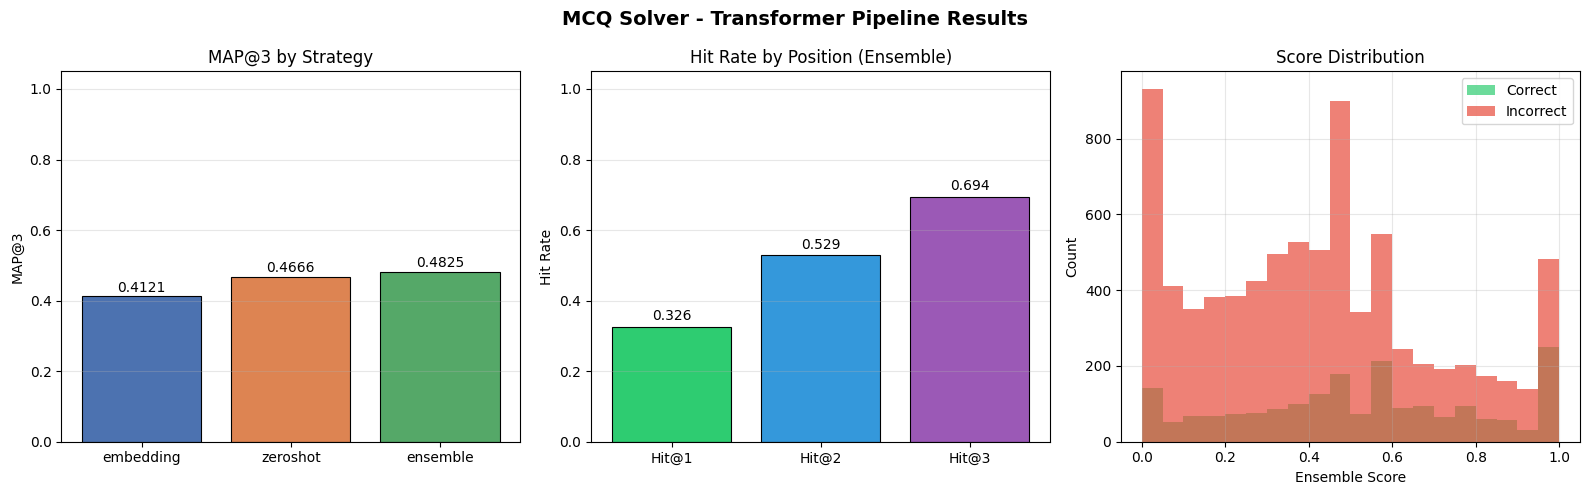

Metrics logged to W&B


In [9]:
# Step 7: Evaluation
pipeline_time = time.time() - total_t0
evaluator, train_metrics, strategy_df = step_evaluate(
    train_data,
    train_results,
    train_emb_scores,
    train_zs_scores,
    ranker,
    pipeline_time,
)

In [10]:
# Step 8: Submission
step_submission(test_results)

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.



STEP 8 : GENERATE SUBMISSION

Validating submission...
Submission valid! 500 rows, 3 predictions each.

Submission Preview:
 ID Prediction
  1      E B D
  2      E B C
  3      E A D
  4      E A D
  5      B D C
  6      D B A
  7      B E C
  8      C D B
  9      A B D
 10      E B C
Submission saved: /kaggle/working/submission.csv


In [21]:
# Finalize W&B
finish_wandb_run(
    run,
    final_metrics={
        f"final_{k}": v
        for k, v in train_metrics.items()
    },
    device_used=DEVICE,
)

print("\n" + "=" * 55)
print("  PIPELINE COMPLETE")
print(f"  Total time : {time.time() - total_t0:.1f}s")
print(f"  Submit     : {SUBMISSION_OUT_PATH}")
print("=" * 55)

UsageError: Run (esialaml) is finished. The call to `_summary_update_callback` will be ignored. Please make sure that you are using an active run.

In [23]:
from pathlib import Path
import shutil

for p in map(Path, [
    "/kaggle/working/Smart-MCQ-Solver",
    "/kaggle/working/results_plot.png",
    "/kaggle/working/wandb",
]):
    shutil.rmtree(p, ignore_errors=True) if p.is_dir() else p.unlink(missing_ok=True)

In [24]:
import os
import shutil

files = {
    "/kaggle/working/models/tfidf.pkl":
        "/kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/models/tfidf.pkl",

    "/kaggle/working/models/w2v.model":
        "/kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/models/w2v.model",

    "/kaggle/working/outputs/processed_files/train_processed.csv":
        "/kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/outputs/processed_files/train_processed.csv",

    "/kaggle/working/outputs/processed_files/test_processed.csv":
        "/kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/outputs/processed_files/test_processed.csv",
}

for dest, src in files.items():
    if not os.path.exists(dest):
        if os.path.exists(src):
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            shutil.copy2(src, dest)
            print(f"Copied: {os.path.basename(dest)}")
        else:
            print(f"Source not found: {src}")
    else:
        print(f"Already exists: {dest}")

Copied: tfidf.pkl
Copied: w2v.model
Already exists: /kaggle/working/outputs/processed_files/train_processed.csv
Already exists: /kaggle/working/outputs/processed_files/test_processed.csv


# Milestone 3

In [2]:
!pip install -r /kaggle/working/Smart-MCQ-Solver/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 49.8 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

In [ ]:
# cell 1
# src/rag/corpus_builder.py
"""
Corpus builder for RAG pipeline.
Converts existing MCQ dataset into retrievable text chunks.
Reuses existing preprocessed CSV — no duplicate preprocessing.
"""

from __future__ import annotations

import logging
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Optional, Dict, Any

import pandas as pd
import numpy as np

logger = logging.getLogger(__name__)


@dataclass
class Chunk:
    """A single retrievable text chunk with metadata."""
    chunk_id: str
    text: str
    source_id: str
    source_type: str          # "question", "option", "combined", "external"
    metadata: Dict[str, Any] = field(default_factory=dict)

    def __len__(self) -> int:
        return len(self.text.split())


@dataclass
class CorpusStats:
    """Statistics about the built corpus."""
    total_chunks: int
    avg_chunk_length: float
    min_chunk_length: int
    max_chunk_length: int
    source_distribution: Dict[str, int]
    vocab_size: int

    def to_dict(self) -> Dict[str, Any]:
        return {
            "total_chunks": self.total_chunks,
            "avg_chunk_length": self.avg_chunk_length,
            "min_chunk_length": self.min_chunk_length,
            "max_chunk_length": self.max_chunk_length,
            "source_distribution": self.source_distribution,
            "vocab_size": self.vocab_size,
        }


class CorpusBuilder:
    """
    Builds a text corpus from the existing MCQ dataset.
    
    Strategy:
      1. Combined chunks: "Question. Answer: A. option_a B. option_b ..."
      2. Question-only chunks
      3. Correct-answer explanation chunks (train only, uses answer label)
    """

    def __init__(
        self,
        chunk_size: int = 256,
        chunk_overlap: int = 32,
        min_chunk_length: int = 50,
    ) -> None:
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.min_chunk_length = min_chunk_length
        self._chunks: List[Chunk] = []

    def build_from_dataframe(
        self,
        df: pd.DataFrame,
        source_type: str = "train",
        option_cols: Optional[List[str]] = None,
        question_col: str = "question",
        answer_col: Optional[str] = "answer",
    ) -> List[Chunk]:
        """
        Build corpus chunks from a processed MCQ dataframe.
        
        Args:
            df: Preprocessed dataframe (reuses existing processed CSV).
            source_type: Label for chunk provenance.
            option_cols: Column names for answer options.
            question_col: Column name for question text.
            answer_col: Column name for correct answer (None for test set).
        
        Returns:
            List of Chunk objects ready for embedding.
        """
        if option_cols is None:
            option_cols = self._detect_option_cols(df)
        
        logger.info(
            "Building corpus from %d rows | options: %s",
            len(df), option_cols
        )
        
        chunks: List[Chunk] = []

        for idx, row in df.iterrows():
            question = self._clean_text(str(row.get(question_col, "")))
            if not question:
                continue

            options_text = self._build_options_text(row, option_cols)
            combined = f"{question} {options_text}".strip()

            # Chunk 1: Full combined context
            chunks.append(Chunk(
                chunk_id=f"{source_type}_{idx}_combined",
                text=combined,
                source_id=str(idx),
                source_type="combined",
                metadata={"row_idx": idx, "source": source_type},
            ))

            # Chunk 2: Question only (useful for question-similarity retrieval)
            if len(question.split()) >= 10:
                chunks.append(Chunk(
                    chunk_id=f"{source_type}_{idx}_question",
                    text=question,
                    source_id=str(idx),
                    source_type="question",
                    metadata={"row_idx": idx, "source": source_type},
                ))

            # Chunk 3: Correct-answer context (train only)
            if answer_col and answer_col in df.columns:
                answer_label = str(row.get(answer_col, "")).strip().upper()
                correct_text = self._get_correct_option_text(
                    row, option_cols, answer_label
                )
                if correct_text:
                    answer_chunk = (
                        f"Question: {question} "
                        f"Correct Answer: {correct_text}"
                    )
                    chunks.append(Chunk(
                        chunk_id=f"{source_type}_{idx}_answer",
                        text=answer_chunk,
                        source_id=str(idx),
                        source_type="answer_context",
                        metadata={
                            "row_idx": idx,
                            "source": source_type,
                            "answer_label": answer_label,
                        },
                    ))

        # Filter short chunks
        before = len(chunks)
        chunks = [c for c in chunks if len(c) >= self.min_chunk_length]
        logger.info(
            "Filtered %d short chunks → %d chunks retained",
            before - len(chunks), len(chunks)
        )

        self._chunks.extend(chunks)
        return chunks

    def build_from_external_texts(
        self,
        texts: List[str],
        source_type: str = "external",
    ) -> List[Chunk]:
        """
        Add external reference texts (e.g., Wikipedia snippets) to corpus.
        Applies sliding-window chunking for long texts.
        """
        chunks: List[Chunk] = []
        for doc_idx, text in enumerate(texts):
            doc_chunks = self._sliding_window_chunk(
                text=self._clean_text(text),
                doc_id=f"{source_type}_{doc_idx}",
                source_type=source_type,
            )
            chunks.extend(doc_chunks)
        
        self._chunks.extend(chunks)
        logger.info("Added %d external chunks", len(chunks))
        return chunks

    def get_all_chunks(self) -> List[Chunk]:
        """Return all accumulated chunks."""
        return self._chunks

    def get_texts(self) -> List[str]:
        """Return plain texts for embedding."""
        return [c.text for c in self._chunks]

    def get_stats(self) -> CorpusStats:
        """Compute corpus statistics for W&B logging."""
        if not self._chunks:
            raise ValueError("No chunks built yet. Call build_from_dataframe first.")
        
        lengths = [len(c) for c in self._chunks]
        source_dist: Dict[str, int] = {}
        for c in self._chunks:
            source_dist[c.source_type] = source_dist.get(c.source_type, 0) + 1
        
        all_words = set()
        for c in self._chunks:
            all_words.update(c.text.lower().split())

        return CorpusStats(
            total_chunks=len(self._chunks),
            avg_chunk_length=float(np.mean(lengths)),
            min_chunk_length=int(np.min(lengths)),
            max_chunk_length=int(np.max(lengths)),
            source_distribution=source_dist,
            vocab_size=len(all_words),
        )

    # ------------------------------------------------------------------ #
    # Private helpers
    # ------------------------------------------------------------------ #

    def _detect_option_cols(self, df: pd.DataFrame) -> List[str]:
        """Auto-detect option columns: option_a/b/c/d or A/B/C/D patterns."""
        candidates = [
            [c for c in df.columns if re.match(r"option_[a-eA-E]", c)],
            [c for c in df.columns if re.match(r"^[A-E]$", c)],
            [c for c in df.columns if c.lower() in ("a", "b", "c", "d", "e")],
            [c for c in df.columns if re.match(r"choice_[0-9]", c)],
        ]
        for cand in candidates:
            if cand:
                logger.info("Detected option columns: %s", cand)
                return sorted(cand)
        raise ValueError(
            "Cannot detect option columns. Pass option_cols explicitly."
        )

    def _build_options_text(
        self, row: pd.Series, option_cols: List[str]
    ) -> str:
        parts = []
        for i, col in enumerate(option_cols):
            label = chr(65 + i)   # A, B, C, ...
            val = str(row.get(col, "")).strip()
            if val and val.lower() != "nan":
                parts.append(f"{label}. {val}")
        return " ".join(parts)

    def _get_correct_option_text(
        self,
        row: pd.Series,
        option_cols: List[str],
        answer_label: str,
    ) -> Optional[str]:
        """Map answer label (e.g. 'A') to the actual option text."""
        label_to_col = {
            chr(65 + i): col for i, col in enumerate(option_cols)
        }
        col = label_to_col.get(answer_label)
        if col and col in row.index:
            text = str(row[col]).strip()
            return text if text.lower() != "nan" else None
        return None

    def _sliding_window_chunk(
        self,
        text: str,
        doc_id: str,
        source_type: str,
    ) -> List[Chunk]:
        """Apply sliding window chunking for long documents."""
        words = text.split()
        if len(words) <= self.chunk_size:
            return [Chunk(
                chunk_id=f"{doc_id}_0",
                text=text,
                source_id=doc_id,
                source_type=source_type,
            )]
        
        chunks = []
        step = self.chunk_size - self.chunk_overlap
        for start in range(0, len(words), step):
            chunk_words = words[start: start + self.chunk_size]
            chunk_text = " ".join(chunk_words)
            if len(chunk_words) < self.min_chunk_length:
                break
            chunks.append(Chunk(
                chunk_id=f"{doc_id}_{start}",
                text=chunk_text,
                source_id=doc_id,
                source_type=source_type,
            ))
        return chunks

    @staticmethod
    def _clean_text(text: str) -> str:
        text = re.sub(r"\s+", " ", text).strip()
        text = re.sub(r"[^\w\s.,!?;:'\"-]", " ", text)
        return text

In [ ]:
# cell 2 
# src/rag/vector_store.py
"""
FAISS vector store for RAG retrieval.
Reuses existing Sentence-BERT embeddings — no new embedding model introduced.
Supports persist/load to avoid rebuilding on every run.
"""

from __future__ import annotations

import json
import logging
import pickle
import time
from pathlib import Path
from typing import List, Tuple, Dict, Any, Optional

import numpy as np

logger = logging.getLogger(__name__)

# Lazy imports — FAISS not always installed outside Kaggle
try:
    import faiss
    FAISS_AVAILABLE = True
except ImportError:
    FAISS_AVAILABLE = False
    logger.warning("FAISS not available. Install faiss-cpu or faiss-gpu.")


class FAISSVectorStore:
    """
    Production FAISS vector store with persistence support.
    
    Design decisions:
      - Uses IVFFlat by default (good speed/accuracy tradeoff on T4)
      - Falls back to Flat index if nlist > corpus size
      - Normalizes embeddings for cosine similarity via IndexFlatIP
      - Stores chunk metadata separately (pickle) alongside FAISS index
    """

    def __init__(
        self,
        embedding_dim: int = 768,
        index_type: str = "IVF",
        nlist: int = 100,
        nprobe: int = 10,
        metric: str = "cosine",
        persist_dir: str = "outputs/vector_store",
        index_name: str = "mcq_corpus",
    ) -> None:
        if not FAISS_AVAILABLE:
            raise RuntimeError("faiss is required. Run: pip install faiss-gpu")
        
        self.embedding_dim = embedding_dim
        self.index_type = index_type
        self.nlist = nlist
        self.nprobe = nprobe
        self.metric = metric
        self.persist_dir = Path(persist_dir)
        self.index_name = index_name
        
        self._index: Optional[faiss.Index] = None
        self._chunks: List[Any] = []          # Chunk objects
        self._embeddings: Optional[np.ndarray] = None
        self._build_time: float = 0.0

        self.persist_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------------------------ #
    # Public API
    # ------------------------------------------------------------------ #

    def build(
        self,
        embeddings: np.ndarray,
        chunks: List[Any],
    ) -> None:
        """
        Build FAISS index from pre-computed embeddings.
        
        Args:
            embeddings: np.ndarray of shape (N, dim) — from existing SBERT pipeline.
            chunks: Parallel list of Chunk objects.
        """
        assert len(embeddings) == len(chunks), (
            f"Embedding count {len(embeddings)} != chunk count {len(chunks)}"
        )
        
        embeddings = self._normalize(embeddings.astype(np.float32))
        self._embeddings = embeddings
        self._chunks = chunks
        
        n_vectors, dim = embeddings.shape
        self.embedding_dim = dim
        
        t0 = time.time()
        self._index = self._create_index(n_vectors, dim)
        self._index.add(embeddings)
        self._build_time = time.time() - t0
        
        logger.info(
            "FAISS index built | type=%s | vectors=%d | dim=%d | time=%.2fs",
            self.index_type, n_vectors, dim, self._build_time
        )

    def search(
        self,
        query_embeddings: np.ndarray,
        top_k: int = 5,
        score_threshold: float = 0.0,
    ) -> List[List[Tuple[Any, float]]]:
        """
        Search for top-k nearest chunks.
        
        Args:
            query_embeddings: (Q, dim) query vectors.
            top_k: Number of results per query.
            score_threshold: Minimum similarity score to include.
        
        Returns:
            List[List[Tuple[Chunk, score]]] — one list per query.
        """
        if self._index is None:
            raise RuntimeError("Index not built. Call build() or load() first.")
        
        query_embeddings = self._normalize(
            query_embeddings.astype(np.float32)
        )
        
        actual_k = min(top_k, self._index.ntotal)
        scores, indices = self._index.search(query_embeddings, actual_k)
        
        results = []
        for q_scores, q_indices in zip(scores, indices):
            q_results = []
            for score, idx in zip(q_scores, q_indices):
                if idx == -1:
                    continue
                if float(score) < score_threshold:
                    continue
                q_results.append((self._chunks[idx], float(score)))
            results.append(q_results)
        
        return results

    def save(self) -> None:
        """Persist index and metadata to disk."""
        index_path = self.persist_dir / f"{self.index_name}.faiss"
        meta_path  = self.persist_dir / f"{self.index_name}_meta.pkl"
        cfg_path   = self.persist_dir / f"{self.index_name}_config.json"
        
        faiss.write_index(self._index, str(index_path))
        
        with open(meta_path, "wb") as f:
            pickle.dump(self._chunks, f)
        
        config = {
            "embedding_dim": self.embedding_dim,
            "index_type": self.index_type,
            "nlist": self.nlist,
            "nprobe": self.nprobe,
            "metric": self.metric,
            "n_vectors": self._index.ntotal,
            "build_time": self._build_time,
        }
        with open(cfg_path, "w") as f:
            json.dump(config, f, indent=2)
        
        logger.info("Vector store saved to %s", self.persist_dir)

    def load(self) -> bool:
        """
        Load persisted index from disk.
        
        Returns:
            True if loaded successfully, False if not found.
        """
        index_path = self.persist_dir / f"{self.index_name}.faiss"
        meta_path  = self.persist_dir / f"{self.index_name}_meta.pkl"
        
        if not index_path.exists() or not meta_path.exists():
            logger.info("No persisted index found at %s", self.persist_dir)
            return False
        
        self._index = faiss.read_index(str(index_path))
        
        # Restore nprobe for IVF indexes
        if hasattr(self._index, "nprobe"):
            self._index.nprobe = self.nprobe
        
        with open(meta_path, "rb") as f:
            self._chunks = pickle.load(f)
        
        logger.info(
            "Vector store loaded | vectors=%d", self._index.ntotal
        )
        return True

    @property
    def n_vectors(self) -> int:
        return self._index.ntotal if self._index else 0

    def get_config(self) -> Dict[str, Any]:
        return {
            "backend": "faiss",
            "index_type": self.index_type,
            "nlist": self.nlist,
            "nprobe": self.nprobe,
            "metric": self.metric,
            "embedding_dim": self.embedding_dim,
            "n_vectors": self.n_vectors,
            "persist_dir": str(self.persist_dir),
        }

    # ------------------------------------------------------------------ #
    # Private helpers
    # ------------------------------------------------------------------ #

    def _create_index(self, n_vectors: int, dim: int) -> faiss.Index:
        """Create appropriate FAISS index based on corpus size."""
        # Cosine similarity via inner product on normalized vectors
        quantizer = faiss.IndexFlatIP(dim)
        
        # Fall back to Flat if corpus too small for IVF
        if self.index_type == "IVF" and n_vectors >= 4 * self.nlist:
            index = faiss.IndexIVFFlat(
                quantizer, dim, self.nlist, faiss.METRIC_INNER_PRODUCT
            )
            index.train(
                self._embeddings if self._embeddings is not None
                else np.random.randn(n_vectors, dim).astype(np.float32)
            )
            index.nprobe = self.nprobe
            logger.info("Using IVFFlat index | nlist=%d nprobe=%d", self.nlist, self.nprobe)
        else:
            index = quantizer
            logger.info("Using Flat index (corpus too small for IVF or Flat requested)")
        
        return index

    @staticmethod
    def _normalize(embeddings: np.ndarray) -> np.ndarray:
        """L2-normalize for cosine similarity via inner product."""
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        norms = np.where(norms == 0, 1e-10, norms)
        return embeddings / norms

In [ ]:
# cell 3
# src/rag/retriever.py
"""
Semantic retriever for RAG pipeline.
Reuses existing Sentence-BERT embedding module — no new embedding model.
"""

from __future__ import annotations

import logging
import time
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Any, Optional, TYPE_CHECKING

import numpy as np
import pandas as pd

from src.rag.vector_store import FAISSVectorStore
from src.rag.corpus_builder import Chunk

if TYPE_CHECKING:
    from sentence_transformers import SentenceTransformer

logger = logging.getLogger(__name__)


@dataclass
class RetrievalResult:
    """Retrieval result for a single query."""
    query: str
    chunks: List[Chunk]
    scores: List[float]
    retrieval_time: float

    @property
    def top_chunk(self) -> Optional[Chunk]:
        return self.chunks[0] if self.chunks else None

    @property
    def combined_context(self) -> str:
        return " ".join(c.text for c in self.chunks)

    @property
    def avg_score(self) -> float:
        return float(np.mean(self.scores)) if self.scores else 0.0

    def to_dict(self) -> Dict[str, Any]:
        return {
            "query": self.query,
            "n_retrieved": len(self.chunks),
            "avg_score": self.avg_score,
            "top_score": self.scores[0] if self.scores else 0.0,
            "retrieval_time": self.retrieval_time,
            "context": self.combined_context,
        }


@dataclass
class RetrievalStats:
    """Aggregate retrieval statistics for W&B logging."""
    total_queries: int
    avg_retrieval_time: float
    avg_score: float
    avg_context_length: float
    top_k: int
    score_threshold: float

    def to_dict(self) -> Dict[str, Any]:
        return {
            "total_queries": self.total_queries,
            "avg_retrieval_time_ms": self.avg_retrieval_time * 1000,
            "avg_similarity_score": self.avg_score,
            "avg_context_tokens": self.avg_context_length,
            "top_k": self.top_k,
            "score_threshold": self.score_threshold,
        }


class SemanticRetriever:
    """
    Semantic retriever using existing SBERT embeddings + FAISS vector store.
    
    Reuse contract:
      - Accepts any encoder that implements .encode(texts) -> np.ndarray
      - Compatible with existing SentenceTransformer instances in the project
    """

    def __init__(
        self,
        encoder: "SentenceTransformer",
        vector_store: FAISSVectorStore,
        top_k: int = 5,
        score_threshold: float = 0.0,
        batch_size: int = 64,
    ) -> None:
        self.encoder = encoder
        self.vector_store = vector_store
        self.top_k = top_k
        self.score_threshold = score_threshold
        self.batch_size = batch_size
        self._results_cache: Dict[str, RetrievalResult] = {}

    def retrieve(
        self,
        queries: List[str],
        top_k: Optional[int] = None,
    ) -> List[RetrievalResult]:
        """
        Retrieve top-k relevant chunks for each query.
        
        Args:
            queries: List of query strings (questions or question+options).
            top_k: Override default top_k.
        
        Returns:
            List of RetrievalResult objects.
        """
        k = top_k or self.top_k
        t0 = time.time()
        
        # Encode all queries in batch — reuses existing SBERT encoder
        query_embeddings = self.encoder.encode(
            queries,
            batch_size=self.batch_size,
            show_progress_bar=len(queries) > 100,
            convert_to_numpy=True,
            normalize_embeddings=False,   # we normalize inside vector store
        )
        
        encode_time = time.time() - t0
        logger.debug("Encoded %d queries in %.2fs", len(queries), encode_time)
        
        # Search vector store
        search_results = self.vector_store.search(
            query_embeddings=query_embeddings,
            top_k=k,
            score_threshold=self.score_threshold,
        )
        
        total_time = time.time() - t0
        per_query_time = total_time / max(len(queries), 1)
        
        results = []
        for query, raw_results in zip(queries, search_results):
            chunks = [r[0] for r in raw_results]
            scores = [r[1] for r in raw_results]
            result = RetrievalResult(
                query=query,
                chunks=chunks,
                scores=scores,
                retrieval_time=per_query_time,
            )
            results.append(result)
        
        logger.info(
            "Retrieved top-%d for %d queries | avg_score=%.4f | total=%.2fs",
            k, len(queries),
            np.mean([r.avg_score for r in results]),
            total_time,
        )
        return results

    def retrieve_for_dataframe(
        self,
        df: pd.DataFrame,
        question_col: str = "question",
        option_cols: Optional[List[str]] = None,
        top_k: Optional[int] = None,
        query_strategy: str = "question_only",
    ) -> List[RetrievalResult]:
        """
        Retrieve for an entire dataframe.
        
        Args:
            df: MCQ dataframe.
            question_col: Column with question text.
            option_cols: Option columns (used if strategy includes options).
            top_k: Number of results to retrieve.
            query_strategy: "question_only" | "question_with_options"
        
        Returns:
            RetrievalResult per row.
        """
        queries = self._build_queries(df, question_col, option_cols, query_strategy)
        return self.retrieve(queries, top_k=top_k)

    def get_stats(self, results: List[RetrievalResult]) -> RetrievalStats:
        """Compute aggregate stats from retrieval results (for W&B)."""
        return RetrievalStats(
            total_queries=len(results),
            avg_retrieval_time=float(np.mean([r.retrieval_time for r in results])),
            avg_score=float(np.mean([r.avg_score for r in results])),
            avg_context_length=float(
                np.mean([len(r.combined_context.split()) for r in results])
            ),
            top_k=self.top_k,
            score_threshold=self.score_threshold,
        )

    # ------------------------------------------------------------------ #
    # Private helpers
    # ------------------------------------------------------------------ #

    def _build_queries(
        self,
        df: pd.DataFrame,
        question_col: str,
        option_cols: Optional[List[str]],
        strategy: str,
    ) -> List[str]:
        queries = []
        for _, row in df.iterrows():
            q = str(row.get(question_col, "")).strip()
            if strategy == "question_only" or not option_cols:
                queries.append(q)
            else:
                opts = " ".join(
                    f"{chr(65+i)}. {str(row.get(c,''))}"
                    for i, c in enumerate(option_cols)
                    if str(row.get(c, "")).lower() not in ("nan", "")
                )
                queries.append(f"{q} {opts}".strip())
        return queries

In [ ]:
# cell 4
# src/rag/retriever.py
"""
Semantic retriever for RAG pipeline.
Reuses existing Sentence-BERT embedding module — no new embedding model.
"""

from __future__ import annotations

import logging
import time
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Any, Optional, TYPE_CHECKING

import numpy as np
import pandas as pd

from src.rag.vector_store import FAISSVectorStore
from src.rag.corpus_builder import Chunk

if TYPE_CHECKING:
    from sentence_transformers import SentenceTransformer

logger = logging.getLogger(__name__)


@dataclass
class RetrievalResult:
    """Retrieval result for a single query."""
    query: str
    chunks: List[Chunk]
    scores: List[float]
    retrieval_time: float

    @property
    def top_chunk(self) -> Optional[Chunk]:
        return self.chunks[0] if self.chunks else None

    @property
    def combined_context(self) -> str:
        return " ".join(c.text for c in self.chunks)

    @property
    def avg_score(self) -> float:
        return float(np.mean(self.scores)) if self.scores else 0.0

    def to_dict(self) -> Dict[str, Any]:
        return {
            "query": self.query,
            "n_retrieved": len(self.chunks),
            "avg_score": self.avg_score,
            "top_score": self.scores[0] if self.scores else 0.0,
            "retrieval_time": self.retrieval_time,
            "context": self.combined_context,
        }


@dataclass
class RetrievalStats:
    """Aggregate retrieval statistics for W&B logging."""
    total_queries: int
    avg_retrieval_time: float
    avg_score: float
    avg_context_length: float
    top_k: int
    score_threshold: float

    def to_dict(self) -> Dict[str, Any]:
        return {
            "total_queries": self.total_queries,
            "avg_retrieval_time_ms": self.avg_retrieval_time * 1000,
            "avg_similarity_score": self.avg_score,
            "avg_context_tokens": self.avg_context_length,
            "top_k": self.top_k,
            "score_threshold": self.score_threshold,
        }


class SemanticRetriever:
    """
    Semantic retriever using existing SBERT embeddings + FAISS vector store.
    
    Reuse contract:
      - Accepts any encoder that implements .encode(texts) -> np.ndarray
      - Compatible with existing SentenceTransformer instances in the project
    """

    def __init__(
        self,
        encoder: "SentenceTransformer",
        vector_store: FAISSVectorStore,
        top_k: int = 5,
        score_threshold: float = 0.0,
        batch_size: int = 64,
    ) -> None:
        self.encoder = encoder
        self.vector_store = vector_store
        self.top_k = top_k
        self.score_threshold = score_threshold
        self.batch_size = batch_size
        self._results_cache: Dict[str, RetrievalResult] = {}

    def retrieve(
        self,
        queries: List[str],
        top_k: Optional[int] = None,
    ) -> List[RetrievalResult]:
        """
        Retrieve top-k relevant chunks for each query.
        
        Args:
            queries: List of query strings (questions or question+options).
            top_k: Override default top_k.
        
        Returns:
            List of RetrievalResult objects.
        """
        k = top_k or self.top_k
        t0 = time.time()
        
        # Encode all queries in batch — reuses existing SBERT encoder
        query_embeddings = self.encoder.encode(
            queries,
            batch_size=self.batch_size,
            show_progress_bar=len(queries) > 100,
            convert_to_numpy=True,
            normalize_embeddings=False,   # we normalize inside vector store
        )
        
        encode_time = time.time() - t0
        logger.debug("Encoded %d queries in %.2fs", len(queries), encode_time)
        
        # Search vector store
        search_results = self.vector_store.search(
            query_embeddings=query_embeddings,
            top_k=k,
            score_threshold=self.score_threshold,
        )
        
        total_time = time.time() - t0
        per_query_time = total_time / max(len(queries), 1)
        
        results = []
        for query, raw_results in zip(queries, search_results):
            chunks = [r[0] for r in raw_results]
            scores = [r[1] for r in raw_results]
            result = RetrievalResult(
                query=query,
                chunks=chunks,
                scores=scores,
                retrieval_time=per_query_time,
            )
            results.append(result)
        
        logger.info(
            "Retrieved top-%d for %d queries | avg_score=%.4f | total=%.2fs",
            k, len(queries),
            np.mean([r.avg_score for r in results]),
            total_time,
        )
        return results

    def retrieve_for_dataframe(
        self,
        df: pd.DataFrame,
        question_col: str = "question",
        option_cols: Optional[List[str]] = None,
        top_k: Optional[int] = None,
        query_strategy: str = "question_only",
    ) -> List[RetrievalResult]:
        """
        Retrieve for an entire dataframe.
        
        Args:
            df: MCQ dataframe.
            question_col: Column with question text.
            option_cols: Option columns (used if strategy includes options).
            top_k: Number of results to retrieve.
            query_strategy: "question_only" | "question_with_options"
        
        Returns:
            RetrievalResult per row.
        """
        queries = self._build_queries(df, question_col, option_cols, query_strategy)
        return self.retrieve(queries, top_k=top_k)

    def get_stats(self, results: List[RetrievalResult]) -> RetrievalStats:
        """Compute aggregate stats from retrieval results (for W&B)."""
        return RetrievalStats(
            total_queries=len(results),
            avg_retrieval_time=float(np.mean([r.retrieval_time for r in results])),
            avg_score=float(np.mean([r.avg_score for r in results])),
            avg_context_length=float(
                np.mean([len(r.combined_context.split()) for r in results])
            ),
            top_k=self.top_k,
            score_threshold=self.score_threshold,
        )

    # ------------------------------------------------------------------ #
    # Private helpers
    # ------------------------------------------------------------------ #

    def _build_queries(
        self,
        df: pd.DataFrame,
        question_col: str,
        option_cols: Optional[List[str]],
        strategy: str,
    ) -> List[str]:
        queries = []
        for _, row in df.iterrows():
            q = str(row.get(question_col, "")).strip()
            if strategy == "question_only" or not option_cols:
                queries.append(q)
            else:
                opts = " ".join(
                    f"{chr(65+i)}. {str(row.get(c,''))}"
                    for i, c in enumerate(option_cols)
                    if str(row.get(c, "")).lower() not in ("nan", "")
                )
                queries.append(f"{q} {opts}".strip())
        return queries

In [ ]:
# cell 5
# src/rag/prompt_builder.py
"""
Prompt builder for RAG-augmented MCQ scoring.
Supports multiple template versions for ablation.
"""

from __future__ import annotations

import logging
from dataclasses import dataclass
from typing import List, Dict, Any, Optional

from src.rag.retriever import RetrievalResult

logger = logging.getLogger(__name__)


# ------------------------------------------------------------------ #
# Template definitions
# ------------------------------------------------------------------ #

TEMPLATES: Dict[str, str] = {
    "v1": (
        "Context:\n{context}\n\n"
        "Question: {question}\n"
        "Options:\n{options}\n\n"
        "Answer:"
    ),
    "v2": (
        "You are an expert assistant. Use the context below to answer "
        "the multiple-choice question. Think step by step.\n\n"
        "Context:\n{context}\n\n"
        "Question: {question}\n"
        "Options:\n{options}\n\n"
        "Based on the context, the correct answer is option"
    ),
    "v3": (
        "Context information:\n{context}\n\n"
        "Given the context above, answer the following question.\n"
        "Question: {question}\n\n"
        "Choose one from:\n{options}\n\n"
        "Reasoning: Let me analyze each option:\n"
        "Answer:"
    ),
    "v2_per_option": (
        "Context:\n{context}\n\n"
        "Question: {question}\n"
        "Is the following a correct answer? Answer with yes or no.\n"
        "Option: {option_text}\n"
        "Answer:"
    ),
}


@dataclass
class BuiltPrompt:
    """A fully constructed prompt with metadata."""
    prompt: str
    question: str
    options: List[str]
    context: str
    template_version: str
    option_label: Optional[str] = None   # for per-option scoring

    def __len__(self) -> int:
        return len(self.prompt.split())

    def to_dict(self) -> Dict[str, Any]:
        return {
            "template_version": self.template_version,
            "prompt_length_tokens": len(self),
            "context_length_tokens": len(self.context.split()),
            "n_options": len(self.options),
        }


class PromptBuilder:
    """
    Builds RAG-augmented prompts for MCQ scoring.
    
    Two scoring strategies:
      1. "joint"      — one prompt for all options (fast, lower accuracy)
      2. "per_option" — one prompt per option (slower, higher accuracy)
    """

    def __init__(
        self,
        template_version: str = "v2",
        max_context_tokens: int = 512,
        strategy: str = "per_option",
    ) -> None:
        if template_version not in TEMPLATES:
            raise ValueError(
                f"Unknown template: {template_version}. "
                f"Available: {list(TEMPLATES.keys())}"
            )
        self.template_version = template_version
        self.max_context_tokens = max_context_tokens
        self.strategy = strategy
        self._template = TEMPLATES[template_version]
        self._per_option_template = TEMPLATES["v2_per_option"]
        logger.info(
            "PromptBuilder | template=%s | strategy=%s | max_ctx=%d",
            template_version, strategy, max_context_tokens
        )

    def build(
        self,
        question: str,
        option_texts: List[str],
        retrieval_result: RetrievalResult,
        option_labels: Optional[List[str]] = None,
    ) -> List[BuiltPrompt]:
        """
        Build prompts for a single MCQ question.
        
        Args:
            question: Question text.
            option_texts: List of answer option texts.
            retrieval_result: Retrieved context for this question.
            option_labels: Labels for each option (["A", "B", ...]).
        
        Returns:
            List[BuiltPrompt] — one per option (per_option) or one total (joint).
        """
        if option_labels is None:
            option_labels = [chr(65 + i) for i in range(len(option_texts))]
        
        context = self._truncate_context(retrieval_result.combined_context)
        
        if self.strategy == "per_option":
            return self._build_per_option(
                question, option_texts, option_labels, context
            )
        else:
            return [self._build_joint(
                question, option_texts, option_labels, context
            )]

    def build_batch(
        self,
        questions: List[str],
        all_option_texts: List[List[str]],
        retrieval_results: List[RetrievalResult],
        all_option_labels: Optional[List[List[str]]] = None,
    ) -> List[List[BuiltPrompt]]:
        """
        Build prompts for a batch of MCQ questions.
        
        Returns:
            List[List[BuiltPrompt]] — one list per question.
        """
        results = []
        for i, (q, opts, ret) in enumerate(
            zip(questions, all_option_texts, retrieval_results)
        ):
            labels = (
                all_option_labels[i] if all_option_labels else None
            )
            results.append(self.build(q, opts, ret, labels))
        return results

    def get_template_info(self) -> Dict[str, Any]:
        return {
            "template_version": self.template_version,
            "strategy": self.strategy,
            "max_context_tokens": self.max_context_tokens,
            "template_text": self._template,
        }

    # ------------------------------------------------------------------ #
    # Private helpers
    # ------------------------------------------------------------------ #

    def _build_per_option(
        self,
        question: str,
        option_texts: List[str],
        option_labels: List[str],
        context: str,
    ) -> List[BuiltPrompt]:
        prompts = []
        for label, text in zip(option_labels, option_texts):
            prompt = self._per_option_template.format(
                context=context,
                question=question,
                option_text=f"{label}. {text}",
            )
            prompts.append(BuiltPrompt(
                prompt=prompt,
                question=question,
                options=option_texts,
                context=context,
                template_version=f"{self.template_version}_per_option",
                option_label=label,
            ))
        return prompts

    def _build_joint(
        self,
        question: str,
        option_texts: List[str],
        option_labels: List[str],
        context: str,
    ) -> BuiltPrompt:
        options_str = "\n".join(
            f"{lbl}. {txt}" for lbl, txt in zip(option_labels, option_texts)
        )
        prompt = self._template.format(
            context=context,
            question=question,
            options=options_str,
        )
        return BuiltPrompt(
            prompt=prompt,
            question=question,
            options=option_texts,
            context=context,
            template_version=self.template_version,
        )

    def _truncate_context(self, context: str) -> str:
        """Hard truncate context to max_context_tokens words."""
        words = context.split()
        if len(words) > self.max_context_tokens:
            words = words[: self.max_context_tokens]
        return " ".join(words)

In [ ]:
# cell 6
# src/rag/rag_scorer.py
"""
RAG-based answer scorer using Flan-T5.
Scores each option independently given retrieved context.
Designed for NVIDIA T4 ×2 GPUs with fp16 inference.
"""

from __future__ import annotations

import logging
import time
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import torch

logger = logging.getLogger(__name__)


class RAGScorer:
    """
    Scores MCQ options using a seq2seq LLM (Flan-T5) with RAG context.
    
    Scoring strategy: per-option yes/no scoring
      - For each option, asks: "Is this the correct answer? yes/no"
      - Score = P(yes) / (P(yes) + P(no))
      - Produces a probability-like score in [0, 1] per option
    
    Fits comfortably on T4 GPU with fp16 and batch_size=8.
    """

    YES_TOKENS = ["yes", "Yes", "YES", "▁yes", "▁Yes"]
    NO_TOKENS  = ["no",  "No",  "NO",  "▁no",  "▁No"]

    def __init__(
        self,
        model_name: str = "google/flan-t5-large",
        device: Optional[str] = None,
        batch_size: int = 8,
        max_new_tokens: int = 8,
        use_fp16: bool = True,
    ) -> None:
        self.model_name = model_name
        self.batch_size = batch_size
        self.max_new_tokens = max_new_tokens
        self.use_fp16 = use_fp16
        self.device = device or (
            "cuda" if torch.cuda.is_available() else "cpu"
        )
        self._model = None
        self._tokenizer = None
        self._yes_ids: List[int] = []
        self._no_ids:  List[int] = []
        self._load_time: float = 0.0

    def load(self) -> None:
        """Load model and tokenizer. Call once before scoring."""
        from transformers import T5ForConditionalGeneration, T5Tokenizer
        
        logger.info("Loading %s on %s ...", self.model_name, self.device)
        t0 = time.time()
        
        self._tokenizer = T5Tokenizer.from_pretrained(self.model_name)
        self._model = T5ForConditionalGeneration.from_pretrained(
            self.model_name,
            torch_dtype=torch.float16 if (
                self.use_fp16 and self.device == "cuda"
            ) else torch.float32,
        ).to(self.device)
        self._model.eval()
        
        # Support multi-GPU (T4 ×2)
        if torch.cuda.device_count() > 1:
            self._model = torch.nn.DataParallel(self._model)
            logger.info("Using %d GPUs", torch.cuda.device_count())
        
        # Resolve yes/no token IDs
        self._yes_ids = [
            self._tokenizer.convert_tokens_to_ids(t)
            for t in self.YES_TOKENS
            if self._tokenizer.convert_tokens_to_ids(t) != self._tokenizer.unk_token_id
        ]
        self._no_ids = [
            self._tokenizer.convert_tokens_to_ids(t)
            for t in self.NO_TOKENS
            if self._tokenizer.convert_tokens_to_ids(t) != self._tokenizer.unk_token_id
        ]
        
        self._load_time = time.time() - t0
        logger.info("Model loaded in %.2fs", self._load_time)

    def score_options(
        self,
        prompts_per_question: List[List[str]],
        n_options_per_question: List[int],
    ) -> List[np.ndarray]:
        """
        Score all options for a batch of questions.
        
        Args:
            prompts_per_question: List[List[str]] — per-option prompts per question.
            n_options_per_question: Number of options per question.
        
        Returns:
            List[np.ndarray] — normalized scores per question, shape (n_options,).
        """
        if self._model is None:
            raise RuntimeError("Model not loaded. Call load() first.")
        
        # Flatten all prompts for batch inference
        flat_prompts: List[str] = []
        for prompts in prompts_per_question:
            flat_prompts.extend(prompts)
        
        flat_scores = self._score_batch(flat_prompts)
        
        # Re-group by question
        results = []
        cursor = 0
        for n_opts in n_options_per_question:
            q_scores = np.array(flat_scores[cursor: cursor + n_opts])
            # Softmax normalization
            q_scores = self._softmax(q_scores)
            results.append(q_scores)
            cursor += n_opts
        
        return results

    def get_config(self) -> Dict[str, Any]:
        return {
            "model_name": self.model_name,
            "device": self.device,
            "batch_size": self.batch_size,
            "max_new_tokens": self.max_new_tokens,
            "use_fp16": self.use_fp16,
            "n_gpus": torch.cuda.device_count(),
            "load_time_s": self._load_time,
        }

    # ------------------------------------------------------------------ #
    # Private helpers
    # ------------------------------------------------------------------ #

    def _score_batch(self, prompts: List[str]) -> List[float]:
        """
        Score a flat list of yes/no prompts.
        Returns P(yes) for each prompt.
        """
        scores = []
        
        for i in range(0, len(prompts), self.batch_size):
            batch = prompts[i: i + self.batch_size]
            
            inputs = self._tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=512,
            ).to(self.device)
            
            with torch.no_grad():
                # Get logits for first generated token
                decoder_input_ids = torch.zeros(
                    (len(batch), 1),
                    dtype=torch.long,
                    device=self.device,
                )
                
                model = (
                    self._model.module
                    if isinstance(self._model, torch.nn.DataParallel)
                    else self._model
                )
                
                outputs = model(
                    input_ids=inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    decoder_input_ids=decoder_input_ids,
                )
                
                logits = outputs.logits[:, 0, :]  # (batch, vocab_size)
                
                # Extract yes/no logits
                yes_logits = logits[:, self._yes_ids].max(dim=-1).values
                no_logits  = logits[:, self._no_ids].max(dim=-1).values
                
                # P(yes) = softmax([yes_logit, no_logit])[0]
                stacked = torch.stack([yes_logits, no_logits], dim=-1)
                probs = torch.softmax(stacked.float(), dim=-1)
                yes_probs = probs[:, 0].cpu().numpy().tolist()
                scores.extend(yes_probs)
        
        return scores

    @staticmethod
    def _softmax(scores: np.ndarray) -> np.ndarray:
        """Numerically stable softmax."""
        e = np.exp(scores - scores.max())
        return e / e.sum()

In [ ]:
# cell 7
# src/rag/rag_pipeline.py
"""
RAG Pipeline orchestrator.
Integrates: Corpus → VectorStore → Retrieval → Prompt → Scoring → Ensemble.
Connects to the existing transformer scoring pipeline.
"""

from __future__ import annotations

import logging
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

from src.rag.corpus_builder import CorpusBuilder, Chunk
from src.rag.vector_store import FAISSVectorStore
from src.rag.retriever import SemanticRetriever, RetrievalResult
from src.rag.prompt_builder import PromptBuilder
from src.rag.rag_scorer import RAGScorer

logger = logging.getLogger(__name__)


@dataclass
class RAGConfig:
    """Typed configuration for the RAG pipeline."""
    # Corpus
    chunk_size: int = 256
    chunk_overlap: int = 32
    min_chunk_length: int = 50

    # Vector store
    index_type: str = "IVF"
    nlist: int = 100
    nprobe: int = 10
    persist_dir: str = "outputs/vector_store"
    index_name: str = "mcq_corpus"

    # Retrieval
    top_k: int = 5
    score_threshold: float = 0.0
    query_strategy: str = "question_only"   # or "question_with_options"

    # Prompt
    template_version: str = "v2"
    max_context_tokens: int = 512
    prompt_strategy: str = "per_option"

    # LLM
    model_name: str = "google/flan-t5-large"
    batch_size: int = 8
    use_fp16: bool = True

    # Ensemble
    rag_weight: float = 0.40
    existing_weight: float = 0.60

    def to_dict(self) -> Dict[str, Any]:
        return {k: v for k, v in self.__dict__.items()}


@dataclass
class RAGOutput:
    """Complete output of one RAG pipeline run."""
    rag_scores: np.ndarray            # shape (N, n_options)
    retrieval_results: List[RetrievalResult]
    ensemble_scores: Optional[np.ndarray] = None  # blended scores
    metadata: Dict[str, Any] = field(default_factory=dict)


class RAGPipeline:
    """
    End-to-end RAG pipeline for MCQ scoring.
    
    Usage:
        pipeline = RAGPipeline(encoder, config)
        pipeline.build_index(train_df)
        output = pipeline.run(test_df, existing_scores)
    """

    def __init__(
        self,
        encoder: SentenceTransformer,
        config: RAGConfig,
    ) -> None:
        self.encoder = encoder
        self.config = config
        
        self.corpus_builder = CorpusBuilder(
            chunk_size=config.chunk_size,
            chunk_overlap=config.chunk_overlap,
            min_chunk_length=config.min_chunk_length,
        )
        self.vector_store = FAISSVectorStore(
            index_type=config.index_type,
            nlist=config.nlist,
            nprobe=config.nprobe,
            persist_dir=config.persist_dir,
            index_name=config.index_name,
        )
        self.retriever: Optional[SemanticRetriever] = None
        self.prompt_builder = PromptBuilder(
            template_version=config.template_version,
            max_context_tokens=config.max_context_tokens,
            strategy=config.prompt_strategy,
        )
        self.rag_scorer = RAGScorer(
            model_name=config.model_name,
            batch_size=config.batch_size,
            use_fp16=config.use_fp16,
        )
        self._is_ready = False

    # ------------------------------------------------------------------ #
    # Phase 1: Index building
    # ------------------------------------------------------------------ #

    def build_index(
        self,
        train_df: pd.DataFrame,
        question_col: str = "question",
        option_cols: Optional[List[str]] = None,
        answer_col: Optional[str] = "answer",
        external_texts: Optional[List[str]] = None,
        force_rebuild: bool = False,
    ) -> Dict[str, Any]:
        """
        Build or load the FAISS vector index from training data.
        
        Reuses existing SBERT embeddings by passing the same encoder.
        Skips rebuild if a persisted index already exists.
        
        Returns:
            Index build metadata for W&B logging.
        """
        t0 = time.time()

        # Try loading existing index first
        if not force_rebuild and self.vector_store.load():
            logger.info("Loaded existing vector store — skipping rebuild.")
            self._init_retriever()
            self._is_ready = True
            return {
                "index_loaded_from_cache": True,
                "n_vectors": self.vector_store.n_vectors,
            }

        # Build corpus
        logger.info("Building corpus from training data (%d rows) ...", len(train_df))
        chunks = self.corpus_builder.build_from_dataframe(
            df=train_df,
            source_type="train",
            option_cols=option_cols,
            question_col=question_col,
            answer_col=answer_col,
        )

        if external_texts:
            self.corpus_builder.build_from_external_texts(
                texts=external_texts, source_type="external"
            )

        all_chunks = self.corpus_builder.get_all_chunks()
        corpus_texts = self.corpus_builder.get_texts()
        corpus_stats = self.corpus_builder.get_stats()

        logger.info(
            "Corpus ready | chunks=%d | avg_length=%.1f words",
            corpus_stats.total_chunks, corpus_stats.avg_chunk_length
        )

        # Embed corpus — reuses existing SBERT encoder
        logger.info("Embedding corpus with SBERT ...")
        t_embed = time.time()
        embeddings = self.encoder.encode(
            corpus_texts,
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True,
        )
        embed_time = time.time() - t_embed
        logger.info(
            "Corpus embedded | shape=%s | time=%.2fs", embeddings.shape, embed_time
        )

        # Build FAISS index
        self.vector_store.build(embeddings=embeddings, chunks=all_chunks)
        self.vector_store.save()

        self._init_retriever()
        self._is_ready = True

        total_time = time.time() - t0
        metadata = {
            "index_loaded_from_cache": False,
            **corpus_stats.to_dict(),
            **self.vector_store.get_config(),
            "embedding_time_s": embed_time,
            "total_build_time_s": total_time,
        }
        return metadata

    # ------------------------------------------------------------------ #
    # Phase 2: Inference
    # ------------------------------------------------------------------ #

    def run(
        self,
        df: pd.DataFrame,
        existing_scores: Optional[np.ndarray] = None,
        question_col: str = "question",
        option_cols: Optional[List[str]] = None,
        top_k: Optional[int] = None,
    ) -> RAGOutput:
        """
        Run RAG inference on the given dataframe.
        
        Args:
            df: MCQ dataframe (test or validation).
            existing_scores: (N, n_options) scores from existing pipeline.
                             If provided, ensemble with RAG scores.
            question_col: Column name for question text.
            option_cols: Option column names.
            top_k: Override retrieval top_k.
        
        Returns:
            RAGOutput with scores and retrieval metadata.
        """
        if not self._is_ready:
            raise RuntimeError("Pipeline not ready. Call build_index() first.")

        self.rag_scorer.load()
        
        if option_cols is None:
            option_cols = self._detect_option_cols(df)
        
        t_total = time.time()

        # Step 1: Retrieve
        logger.info("Retrieving context for %d questions ...", len(df))
        retrieval_results = self.retriever.retrieve_for_dataframe(
            df=df,
            question_col=question_col,
            option_cols=option_cols,
            top_k=top_k or self.config.top_k,
            query_strategy=self.config.query_strategy,
        )

        # Step 2: Build prompts
        logger.info("Building prompts ...")
        questions = df[question_col].tolist()
        all_option_texts = self._extract_option_texts(df, option_cols)

        prompts_per_question = self.prompt_builder.build_batch(
            questions=questions,
            all_option_texts=all_option_texts,
            retrieval_results=retrieval_results,
        )

        # Step 3: Score with LLM
        logger.info("Scoring with RAG scorer ...")
        t_score = time.time()
        flat_prompts_per_q = [
            [p.prompt for p in prompts] for prompts in prompts_per_question
        ]
        n_options_per_q = [len(opts) for opts in all_option_texts]

        rag_scores = self.rag_scorer.score_options(
            prompts_per_question=flat_prompts_per_q,
            n_options_per_question=n_options_per_q,
        )
        score_time = time.time() - t_score

        # Pad to uniform shape for numpy stacking
        max_opts = max(len(s) for s in rag_scores)
        rag_scores_np = np.zeros((len(rag_scores), max_opts))
        for i, scores in enumerate(rag_scores):
            rag_scores_np[i, : len(scores)] = scores

        # Step 4: Ensemble
        ensemble_scores = None
        if existing_scores is not None:
            ensemble_scores = self._ensemble(rag_scores_np, existing_scores)

        total_time = time.time() - t_total
        retrieval_stats = self.retriever.get_stats(retrieval_results)

        metadata = {
            "n_questions": len(df),
            "scoring_time_s": score_time,
            "total_inference_time_s": total_time,
            **retrieval_stats.to_dict(),
            **self.rag_scorer.get_config(),
            **self.prompt_builder.get_template_info(),
        }

        logger.info(
            "RAG inference complete | n=%d | score_time=%.2fs | total=%.2fs",
            len(df), score_time, total_time
        )

        return RAGOutput(
            rag_scores=rag_scores_np,
            retrieval_results=retrieval_results,
            ensemble_scores=ensemble_scores,
            metadata=metadata,
        )

    # ------------------------------------------------------------------ #
    # Private helpers
    # ------------------------------------------------------------------ #

    def _init_retriever(self) -> None:
        self.retriever = SemanticRetriever(
            encoder=self.encoder,
            vector_store=self.vector_store,
            top_k=self.config.top_k,
            score_threshold=self.config.score_threshold,
        )

    def _ensemble(
        self,
        rag_scores: np.ndarray,
        existing_scores: np.ndarray,
    ) -> np.ndarray:
        """Weighted linear ensemble of RAG and existing scores."""
        # Normalize both to [0, 1] range
        rag_norm = self._minmax_normalize(rag_scores)
        ext_norm = self._minmax_normalize(existing_scores)
        blended = (
            self.config.rag_weight * rag_norm
            + self.config.existing_weight * ext_norm
        )
        return blended

    @staticmethod
    def _minmax_normalize(scores: np.ndarray) -> np.ndarray:
        min_val = scores.min(axis=1, keepdims=True)
        max_val = scores.max(axis=1, keepdims=True)
        denom = np.where(max_val - min_val == 0, 1e-10, max_val - min_val)
        return (scores - min_val) / denom

    def _extract_option_texts(
        self, df: pd.DataFrame, option_cols: List[str]
    ) -> List[List[str]]:
        all_options = []
        for _, row in df.iterrows():
            opts = [
                str(row.get(col, "")).strip()
                for col in option_cols
                if str(row.get(col, "")).lower() not in ("nan", "")
            ]
            all_options.append(opts)
        return all_options

    @staticmethod
    def _detect_option_cols(df: pd.DataFrame) -> List[str]:
        import re
        for pattern in [r"option_[a-eA-E]", r"^[A-E]$"]:
            cols = sorted([c for c in df.columns if re.match(pattern, c)])
            if cols:
                return cols
        raise ValueError("Cannot auto-detect option columns.")

In [ ]:
# cell 8
# src/evaluation/rag_evaluator.py
"""
RAG evaluation utilities.
Extends existing MAP@3 evaluation — does not modify existing evaluator.
Provides baseline vs RAG comparison and ablation study support.
"""

from __future__ import annotations

import logging
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd

logger = logging.getLogger(__name__)


def map_at_3(
    predictions: List[List[str]],
    ground_truths: List[str],
) -> float:
    """
    Compute MAP@3.
    
    Args:
        predictions: List of top-3 predicted option labels per question.
        ground_truths: Correct answer label per question.
    
    Returns:
        MAP@3 score in [0, 1].
    """
    ap_sum = 0.0
    for preds, gt in zip(predictions, ground_truths):
        preds_k = preds[:3]
        ap = 0.0
        hits = 0
        for rank, pred in enumerate(preds_k, start=1):
            if pred == gt:
                hits += 1
                ap += hits / rank
        ap_sum += ap
    return ap_sum / len(ground_truths) if ground_truths else 0.0


def scores_to_top3(
    scores: np.ndarray,
    option_labels: List[str],
) -> List[List[str]]:
    """
    Convert score matrix to ranked top-3 option labels.
    
    Args:
        scores: (N, n_options) score matrix (higher = better).
        option_labels: Labels for each option column.
    
    Returns:
        List[List[str]] — top-3 labels per question.
    """
    predictions = []
    for row_scores in scores:
        valid_mask = row_scores > -np.inf
        ranked_indices = np.argsort(row_scores[valid_mask])[::-1][:3]
        top3 = [option_labels[i] for i in ranked_indices]
        predictions.append(top3)
    return predictions


@dataclass
class EvalResult:
    """Single evaluation result."""
    name: str
    map3: float
    predictions: List[List[str]]
    metadata: Dict[str, Any] = field(default_factory=dict)

    def to_dict(self) -> Dict[str, Any]:
        return {"name": self.name, "map3": self.map3, **self.metadata}


@dataclass
class ComparisonResult:
    """Baseline vs RAG comparison."""
    baseline: EvalResult
    rag: EvalResult
    improvement: float
    relative_improvement_pct: float
    ablation_results: List[EvalResult] = field(default_factory=list)

    def to_dict(self) -> Dict[str, Any]:
        return {
            "baseline_map3": self.baseline.map3,
            "rag_map3": self.rag.map3,
            "improvement": self.improvement,
            "relative_improvement_pct": self.relative_improvement_pct,
            "ablation": [r.to_dict() for r in self.ablation_results],
        }

    def print_report(self) -> None:
        print("\n" + "=" * 55)
        print("  EVALUATION REPORT: Baseline vs RAG")
        print("=" * 55)
        print(f"  Baseline MAP@3 : {self.baseline.map3:.4f}")
        print(f"  RAG      MAP@3 : {self.rag.map3:.4f}")
        print(f"  Δ MAP@3        : {self.improvement:+.4f}")
        print(f"  Relative Δ     : {self.relative_improvement_pct:+.2f}%")
        if self.ablation_results:
            print("\n  Ablation Results:")
            for r in self.ablation_results:
                print(f"    {r.name:<30} MAP@3={r.map3:.4f}")
        print("=" * 55 + "\n")


class RAGEvaluator:
    """
    Evaluates and compares baseline vs RAG performance.
    Supports ablation studies over top_k and ensemble weights.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        answer_col: str = "answer",
        option_cols: Optional[List[str]] = None,
    ) -> None:
        self.df = df
        self.answer_col = answer_col
        self.option_cols = option_cols or self._detect_option_cols(df)
        self.option_labels = [
            chr(65 + i) for i in range(len(self.option_cols))
        ]
        self.ground_truths = df[answer_col].astype(str).str.strip().str.upper().tolist()

    def evaluate(
        self,
        scores: np.ndarray,
        name: str = "model",
        metadata: Optional[Dict[str, Any]] = None,
    ) -> EvalResult:
        """Evaluate a score matrix against ground truth."""
        predictions = scores_to_top3(scores, self.option_labels)
        map3 = map_at_3(predictions, self.ground_truths)
        return EvalResult(
            name=name,
            map3=map3,
            predictions=predictions,
            metadata=metadata or {},
        )

    def compare(
        self,
        baseline_scores: np.ndarray,
        rag_scores: np.ndarray,
        ablation_scores: Optional[List[Tuple[str, np.ndarray]]] = None,
    ) -> ComparisonResult:
        """
        Compare baseline and RAG, with optional ablation results.
        
        Args:
            baseline_scores: (N, n_options) existing pipeline scores.
            rag_scores: (N, n_options) RAG ensemble scores.
            ablation_scores: List of (name, scores) for ablation runs.
        
        Returns:
            ComparisonResult with full report data.
        """
        baseline_result = self.evaluate(baseline_scores, name="baseline")
        rag_result      = self.evaluate(rag_scores, name="rag")
        
        improvement = rag_result.map3 - baseline_result.map3
        relative_pct = (
            100 * improvement / baseline_result.map3
            if baseline_result.map3 > 0 else 0.0
        )
        
        ablation_results = []
        if ablation_scores:
            for abl_name, abl_scores in ablation_scores:
                ablation_results.append(
                    self.evaluate(abl_scores, name=abl_name)
                )
        
        result = ComparisonResult(
            baseline=baseline_result,
            rag=rag_result,
            improvement=improvement,
            relative_improvement_pct=relative_pct,
            ablation_results=ablation_results,
        )
        result.print_report()
        return result

    def ablation_over_top_k(
        self,
        run_fn,   # callable: (top_k: int) -> np.ndarray
        top_k_values: List[int],
    ) -> List[EvalResult]:
        """
        Run ablation study over different top_k retrieval values.
        
        Args:
            run_fn: Function that takes top_k and returns score matrix.
            top_k_values: List of top_k values to test.
        
        Returns:
            List of EvalResult, one per top_k value.
        """
        results = []
        for k in top_k_values:
            logger.info("Ablation: top_k=%d", k)
            scores = run_fn(k)
            result = self.evaluate(scores, name=f"top_k={k}")
            results.append(result)
            logger.info("  top_k=%d → MAP@3=%.4f", k, result.map3)
        return results

    def ablation_over_weights(
        self,
        rag_scores: np.ndarray,
        baseline_scores: np.ndarray,
        weight_pairs: Optional[List[Tuple[float, float]]] = None,
    ) -> List[EvalResult]:
        """
        Ablation over ensemble weight combinations.
        
        Args:
            rag_scores: RAG score matrix.
            baseline_scores: Baseline score matrix.
            weight_pairs: [(rag_weight, baseline_weight), ...]
        
        Returns:
            List of EvalResult for each weight pair.
        """
        if weight_pairs is None:
            weight_pairs = [
                (0.1, 0.9), (0.2, 0.8), (0.3, 0.7),
                (0.4, 0.6), (0.5, 0.5), (0.6, 0.4),
                (0.7, 0.3),
            ]
        
        results = []
        for rag_w, base_w in weight_pairs:
            blended = rag_w * self._normalize(rag_scores) + base_w * self._normalize(baseline_scores)
            result = self.evaluate(
                blended,
                name=f"rag={rag_w:.1f}_base={base_w:.1f}",
                metadata={"rag_weight": rag_w, "base_weight": base_w},
            )
            results.append(result)
            logger.info(
                "  weights rag=%.1f base=%.1f → MAP@3=%.4f",
                rag_w, base_w, result.map3
            )
        return results

    # ------------------------------------------------------------------ #
    # Private helpers
    # ------------------------------------------------------------------ #

    @staticmethod
    def _detect_option_cols(df: pd.DataFrame) -> List[str]:
        import re
        for pattern in [r"option_[a-eA-E]", r"^[A-E]$"]:
            cols = sorted([c for c in df.columns if re.match(pattern, c)])
            if cols:
                return cols
        raise ValueError("Cannot auto-detect option columns.")

    @staticmethod
    def _normalize(scores: np.ndarray) -> np.ndarray:
        min_val = scores.min(axis=1, keepdims=True)
        max_val = scores.max(axis=1, keepdims=True)
        denom = np.where(max_val - min_val == 0, 1e-10, max_val - min_val)
        return (scores - min_val) / denom

In [ ]:
# cell 9
# utils/rag_wandb_utils.py
"""
RAG-specific W&B logging utilities.
STRICTLY reuses functions from utils/wandb_utils.py.
Adds RAG metadata, artifacts, and ablation logging.
"""

from __future__ import annotations

import json
import logging
import os
from pathlib import Path
from typing import Any, Dict, List, Optional, TYPE_CHECKING

if TYPE_CHECKING:
    from src.evaluation.rag_evaluator import ComparisonResult, EvalResult, RAGOutput

logger = logging.getLogger(__name__)

# Guard: only import wandb when available
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False


def log_rag_config(config_dict: Dict[str, Any]) -> None:
    """Log RAG configuration to active W&B run."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    wandb.config.update({"rag": config_dict}, allow_val_change=True)
    logger.debug("Logged RAG config to W&B")


def log_index_build_metadata(metadata: Dict[str, Any]) -> None:
    """Log vector store build statistics."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    wandb.log({f"vector_store/{k}": v for k, v in metadata.items()})
    logger.debug("Logged index build metadata to W&B")


def log_retrieval_stats(stats_dict: Dict[str, Any]) -> None:
    """Log retrieval performance statistics."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    wandb.log({f"retrieval/{k}": v for k, v in stats_dict.items()})


def log_inference_metadata(metadata: Dict[str, Any]) -> None:
    """Log RAG inference metadata (timing, GPU, prompt info)."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    wandb.log({f"inference/{k}": v for k, v in metadata.items()})


def log_comparison_result(comparison: "ComparisonResult") -> None:
    """Log baseline vs RAG MAP@3 comparison."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    
    wandb.log({
        "eval/baseline_map3": comparison.baseline.map3,
        "eval/rag_map3": comparison.rag.map3,
        "eval/improvement": comparison.improvement,
        "eval/relative_improvement_pct": comparison.relative_improvement_pct,
    })
    
    # Ablation table
    if comparison.ablation_results:
        table = wandb.Table(
            columns=["experiment", "map3"],
            data=[
                [r.name, r.map3]
                for r in comparison.ablation_results
            ],
        )
        wandb.log({"ablation/results_table": table})
    
    logger.info(
        "W&B | baseline=%.4f | rag=%.4f | Δ=%+.4f",
        comparison.baseline.map3,
        comparison.rag.map3,
        comparison.improvement,
    )


def log_ablation_top_k(results: List["EvalResult"]) -> None:
    """Log top_k ablation results as a W&B table."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    
    table = wandb.Table(
        columns=["top_k", "map3"],
        data=[
            [r.name.replace("top_k=", ""), r.map3]
            for r in results
        ],
    )
    wandb.log({"ablation/top_k_table": table})


def log_ablation_weights(results: List["EvalResult"]) -> None:
    """Log ensemble weight ablation results."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    
    table = wandb.Table(
        columns=["experiment", "rag_weight", "base_weight", "map3"],
        data=[
            [
                r.name,
                r.metadata.get("rag_weight", ""),
                r.metadata.get("base_weight", ""),
                r.map3,
            ]
            for r in results
        ],
    )
    wandb.log({"ablation/weight_table": table})


def log_submission_artifact(
    submission_path: str,
    metadata: Optional[Dict[str, Any]] = None,
) -> None:
    """Upload submission CSV as a W&B artifact."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    
    artifact = wandb.Artifact(
        name="rag_submission",
        type="submission",
        metadata=metadata or {},
    )
    artifact.add_file(submission_path)
    wandb.log_artifact(artifact)
    logger.info("Submission artifact logged to W&B")


def log_prompt_template_artifact(template_info: Dict[str, Any]) -> None:
    """Log prompt template as a W&B artifact."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    
    tmp_path = Path("outputs/prompt_template.json")
    tmp_path.parent.mkdir(parents=True, exist_ok=True)
    with open(tmp_path, "w") as f:
        json.dump(template_info, f, indent=2)
    
    artifact = wandb.Artifact(name="prompt_template", type="config")
    artifact.add_file(str(tmp_path))
    wandb.log_artifact(artifact)


def log_retrieval_log_artifact(
    retrieval_results: List[Any],
    n_samples: int = 50,
) -> None:
    """Log a sample of retrieval results as a W&B table artifact."""
    if not WANDB_AVAILABLE or wandb.run is None:
        return
    
    table = wandb.Table(
        columns=["query", "top_chunk", "score", "retrieval_time_ms"],
        data=[
            [
                r.query[:100],
                r.top_chunk.text[:200] if r.top_chunk else "",
                round(r.scores[0], 4) if r.scores else 0.0,
                round(r.retrieval_time * 1000, 2),
            ]
            for r in retrieval_results[:n_samples]
        ],
    )
    wandb.log({"retrieval/sample_log": table})

In [ ]:
# cell 10 
# scripts/run_rag_pipeline.py
"""
RAG Pipeline CLI script.
Integrates with existing project structure.
Reuses all existing modules; adds RAG on top.

Usage:
    python scripts/run_rag_pipeline.py \
        --train_path data/processed/train.csv \
        --test_path  data/processed/test.csv \
        --config     config/rag_config.yaml \
        --top_k      5 \
        --rag_weight 0.4
"""

from __future__ import annotations

import argparse
import logging
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

# Add project root to path
sys.path.insert(0, str(Path(__file__).resolve().parent.parent))

from sentence_transformers import SentenceTransformer

from src.rag import RAGPipeline, RAGConfig
from src.evaluation.rag_evaluator import RAGEvaluator
from utils.rag_wandb_utils import (
    log_rag_config,
    log_index_build_metadata,
    log_inference_metadata,
    log_comparison_result,
    log_ablation_top_k,
    log_ablation_weights,
    log_submission_artifact,
    log_prompt_template_artifact,
    log_retrieval_log_artifact,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger("run_rag_pipeline")


# ------------------------------------------------------------------ #
# Argument parsing
# ------------------------------------------------------------------ #

def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="RAG Pipeline for Smart MCQ Solver")
    
    parser.add_argument("--train_path", required=True)
    parser.add_argument("--test_path",  required=True)
    parser.add_argument("--config",     default="config/rag_config.yaml")
    parser.add_argument("--output_dir", default="outputs/rag")
    
    # Overrides
    parser.add_argument("--top_k",         type=int,   default=None)
    parser.add_argument("--rag_weight",    type=float, default=None)
    parser.add_argument("--template",      type=str,   default=None)
    parser.add_argument("--model_name",    type=str,   default=None)
    parser.add_argument("--sbert_model",   type=str,   default=None)
    parser.add_argument("--force_rebuild", action="store_true")
    parser.add_argument("--ablation",      action="store_true")
    parser.add_argument("--wandb",         action="store_true")
    parser.add_argument("--wandb_project", type=str, default="smart-mcq-rag")
    
    return parser.parse_args()


# ------------------------------------------------------------------ #
# Config loading
# ------------------------------------------------------------------ #

def load_rag_config(config_path: str, args: argparse.Namespace) -> RAGConfig:
    """Load YAML config and apply CLI overrides."""
    cfg = {}
    if Path(config_path).exists():
        with open(config_path) as f:
            raw = yaml.safe_load(f)
        cfg = raw.get("rag", {})
    
    rag_cfg = RAGConfig(
        chunk_size=cfg.get("corpus", {}).get("chunk_size", 256),
        chunk_overlap=cfg.get("corpus", {}).get("chunk_overlap", 32),
        min_chunk_length=cfg.get("corpus", {}).get("min_chunk_length", 50),
        index_type=cfg.get("vector_store", {}).get("index_type", "IVF"),
        nlist=cfg.get("vector_store", {}).get("nlist", 100),
        nprobe=cfg.get("vector_store", {}).get("nprobe", 10),
        persist_dir=cfg.get("vector_store", {}).get("persist_dir", "outputs/vector_store"),
        index_name=cfg.get("vector_store", {}).get("index_name", "mcq_corpus"),
        top_k=cfg.get("retrieval", {}).get("top_k_default", 5),
        score_threshold=cfg.get("retrieval", {}).get("score_threshold", 0.0),
        template_version=cfg.get("prompt", {}).get("template_version", "v2"),
        max_context_tokens=cfg.get("prompt", {}).get("max_context_tokens", 512),
        prompt_strategy=cfg.get("prompt", {}).get("strategy", "per_option"),
        model_name=cfg.get("model", {}).get("name", "google/flan-t5-large"),
        batch_size=cfg.get("model", {}).get("batch_size", 8),
        use_fp16=cfg.get("model", {}).get("use_fp16", True),
        rag_weight=cfg.get("ensemble", {}).get("rag_weight", 0.40),
    )
    
    # CLI overrides
    if args.top_k:         rag_cfg.top_k          = args.top_k
    if args.rag_weight:    rag_cfg.rag_weight       = args.rag_weight
    if args.template:      rag_cfg.template_version = args.template
    if args.model_name:    rag_cfg.model_name       = args.model_name
    
    return rag_cfg


# ------------------------------------------------------------------ #
# Baseline score loader
# ------------------------------------------------------------------ #

def load_or_compute_baseline(
    df: pd.DataFrame,
    encoder: SentenceTransformer,
    question_col: str,
    option_cols: list,
    output_dir: Path,
    split: str = "train",
) -> np.ndarray:
    """Load cached baseline scores or compute from SBERT similarity."""
    cache_path = output_dir / f"baseline_scores_{split}.npy"
    if cache_path.exists():
        scores = np.load(str(cache_path))
        logger.info("Loaded baseline scores from %s | shape=%s", cache_path, scores.shape)
        return scores
    
    import re as _re
    
    def clean(t: str) -> str:
        return _re.sub(r"\s+", " ", str(t)).strip()
    
    questions = [clean(r.get(question_col, "")) for _, r in df.iterrows()]
    q_embs = encoder.encode(
        questions, batch_size=64, show_progress_bar=True, convert_to_numpy=True
    )
    q_norm = q_embs / (np.linalg.norm(q_embs, axis=1, keepdims=True) + 1e-10)
    
    n, n_opts = len(df), len(option_cols)
    scores = np.zeros((n, n_opts))
    
    for i, col in enumerate(option_cols):
        opts = [clean(str(r.get(col, ""))) for _, r in df.iterrows()]
        o_embs = encoder.encode(opts, batch_size=64, show_progress_bar=False, convert_to_numpy=True)
        o_norm = o_embs / (np.linalg.norm(o_embs, axis=1, keepdims=True) + 1e-10)
        scores[:, i] = (q_norm * o_norm).sum(axis=1)
    
    np.save(str(cache_path), scores)
    logger.info("Baseline scores saved: %s | shape=%s", cache_path, scores.shape)
    return scores


# ------------------------------------------------------------------ #
# Submission generator
# ------------------------------------------------------------------ #

def generate_submission(
    df: pd.DataFrame,
    predictions: list,
    output_path: Path,
    id_col: str = None,
) -> pd.DataFrame:
    import re as _re
    if id_col is None:
        id_col = next(
            (c for c in df.columns if _re.match(r"^(id|question_id|index)$", c.lower())),
            None
        )
    rows = []
    for idx, (_, row) in enumerate(df.iterrows()):
        qid = row[id_col] if id_col and id_col in row else idx
        rows.append({"id": qid, "prediction": " ".join(predictions[idx])})
    
    sub = pd.DataFrame(rows)
    sub.to_csv(str(output_path), index=False)
    logger.info("Submission saved: %s (%d rows)", output_path, len(sub))
    return sub


# ------------------------------------------------------------------ #
# Main
# ------------------------------------------------------------------ #

def main() -> None:
    args = parse_args()
    t_start = time.time()
    
    output_dir = Path(args.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Load config
    rag_cfg = load_rag_config(args.config, args)
    logger.info("RAG Config: %s", rag_cfg.to_dict())
    
    # W&B init (reuses existing wandb_utils pattern)
    if args.wandb:
        try:
            from utils.wandb_utils import authenticate_wandb, init_wandb_run
            authenticate_wandb()
            init_wandb_run(
                project=args.wandb_project,
                name=f"rag_{int(time.time())}",
                config=rag_cfg.to_dict(),
                tags=["rag", "faiss", "flan-t5", "map@3"],
            )
            log_rag_config(rag_cfg.to_dict())
        except Exception as e:
            logger.warning("W&B init failed: %s", e)
    
    # Load data
    train_df = pd.read_csv(args.train_path)
    test_df  = pd.read_csv(args.test_path)
    logger.info("Train: %s | Test: %s", train_df.shape, test_df.shape)
    
    # Auto-detect columns
    import re as _re
    def detect_option_cols(df):
        for pat in [r"option_[a-eA-E]", r"^[A-E]$"]:
            cols = sorted([c for c in df.columns if _re.match(pat, c)])
            if cols: return cols
        raise ValueError("Cannot detect option columns")
    
    def detect_question_col(df):
        for name in ["question", "Question", "prompt", "stem"]:
            if name in df.columns: return name
        raise ValueError("Cannot detect question column")
    
    def detect_answer_col(df):
        for name in ["answer", "Answer", "correct_answer", "label"]:
            if name in df.columns: return name
        return None
    
    QUESTION_COL = detect_question_col(train_df)
    OPTION_COLS  = detect_option_cols(train_df)
    ANSWER_COL   = detect_answer_col(train_df)
    OPTION_LABELS = [chr(65 + i) for i in range(len(OPTION_COLS))]
    
    logger.info(
        "Detected | question=%s | options=%s | answer=%s",
        QUESTION_COL, OPTION_COLS, ANSWER_COL
    )
    
    # Load SBERT encoder (reuse existing)
    sbert_name = args.sbert_model or "sentence-transformers/all-mpnet-base-v2"
    logger.info("Loading SBERT: %s", sbert_name)
    encoder = SentenceTransformer(sbert_name)
    
    # Build/load baseline scores
    train_baseline = load_or_compute_baseline(
        train_df, encoder, QUESTION_COL, OPTION_COLS, output_dir, split="train"
    )
    test_baseline = load_or_compute_baseline(
        test_df, encoder, QUESTION_COL, OPTION_COLS, output_dir, split="test"
    )
    
    # Build RAG pipeline
    pipeline = RAGPipeline(encoder=encoder, config=rag_cfg)
    
    index_meta = pipeline.build_index(
        train_df=train_df,
        question_col=QUESTION_COL,
        option_cols=OPTION_COLS,
        answer_col=ANSWER_COL,
        force_rebuild=args.force_rebuild,
    )
    log_index_build_metadata(index_meta)
    
    # Run RAG on train (validation)
    logger.info("Running RAG on train split ...")
    train_output = pipeline.run(
        df=train_df,
        existing_scores=train_baseline,
        question_col=QUESTION_COL,
        option_cols=OPTION_COLS,
    )
    log_inference_metadata(train_output.metadata)
    log_retrieval_log_artifact(train_output.retrieval_results)
    log_prompt_template_artifact(pipeline.prompt_builder.get_template_info())
    
    # Evaluate
    evaluator = RAGEvaluator(
        df=train_df,
        answer_col=ANSWER_COL,
        option_cols=OPTION_COLS,
    ) if ANSWER_COL else None
    
    comparison = None
    if evaluator:
        ablation_scores = None
        if args.ablation:
            # Top-K ablation
            topk_results = evaluator.ablation_over_top_k(
                run_fn=lambda k: pipeline.run(
                    train_df, train_baseline, QUESTION_COL, OPTION_COLS, top_k=k
                ).ensemble_scores,
                top_k_values=[3, 5, 10],
            )
            log_ablation_top_k(topk_results)
            
            # Weight ablation
            weight_results = evaluator.ablation_over_weights(
                rag_scores=train_output.rag_scores,
                baseline_scores=train_baseline,
            )
            log_ablation_weights(weight_results)
            
            ablation_scores = [
                (r.name, train_output.ensemble_scores) for r in topk_results
            ]
        
        comparison = evaluator.compare(
            baseline_scores=train_baseline,
            rag_scores=train_output.ensemble_scores,
            ablation_scores=ablation_scores,
        )
        log_comparison_result(comparison)
    
    # Run RAG on test
    logger.info("Running RAG on test split ...")
    test_output = pipeline.run(
        df=test_df,
        existing_scores=test_baseline,
        question_col=QUESTION_COL,
        option_cols=OPTION_COLS,
    )
    
    from src.evaluation.rag_evaluator import scores_to_top3
    test_preds = scores_to_top3(test_output.ensemble_scores, OPTION_LABELS)
    
    # Generate submission
    submission_path = output_dir / "submission_rag.csv"
    generate_submission(test_df, test_preds, submission_path)
    log_submission_artifact(
        str(submission_path),
        metadata=comparison.to_dict() if comparison else {},
    )
    
    total_time = time.time() - t_start
    logger.info("Total runtime: %.2fs", total_time)
    
    # Finish W&B
    if args.wandb:
        try:
            from utils.wandb_utils import finish_wandb_run
            finish_wandb_run()
        except Exception:
            pass


if __name__ == "__main__":
    main()

In [ ]:
# notebooks/rag_mcq_solver.py
# ============================================================
# Smart MCQ Solver — RAG Integration
# Kaggle Notebook | NVIDIA T4 ×2 | MAP@3 Target: 0.76+
# ============================================================

# ── Cell 1: Environment setup ─────────────────────────────────
import subprocess, sys

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)

pip_install([
    "faiss-gpu",
    "sentence-transformers",
    "transformers>=4.35.0",
    "accelerate",
    "wandb",
    "datasets",
])

# ── Cell 2: Imports ───────────────────────────────────────────
import os
import json
import logging
import time
import warnings
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from transformers import T5ForConditionalGeneration, T5Tokenizer
import faiss

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger("rag_notebook")

# ── Cell 3: Configuration ─────────────────────────────────────
CONFIG = {
    # Paths — update for your Kaggle dataset paths
    "train_path":  "/kaggle/input/your-dataset/train.csv",
    "test_path":   "/kaggle/input/your-dataset/test.csv",
    "output_dir":  "/kaggle/working/outputs",
    "index_dir":   "/kaggle/working/vector_store",

    # Corpus
    "chunk_size":        256,
    "chunk_overlap":     32,
    "min_chunk_length":  30,

    # SBERT — reuse existing model
    "sbert_model":      "sentence-transformers/all-mpnet-base-v2",
    "sbert_batch_size":  64,

    # FAISS
    "index_type":  "IVF",
    "nlist":       100,
    "nprobe":      10,

    # Retrieval ablation
    "top_k_values":  [3, 5, 10],
    "top_k_default": 5,

    # Prompt
    "template_version":   "v2",
    "max_context_tokens": 400,
    "prompt_strategy":    "per_option",

    # LLM
    "llm_model":      "google/flan-t5-large",
    "llm_batch_size":  8,
    "use_fp16":        True,

    # Ensemble ablation weights
    "rag_weights": [0.2, 0.3, 0.4, 0.5],

    # W&B
    "wandb_project": "smart-mcq-rag",
    "wandb_enabled": True,
}

Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
Path(CONFIG["index_dir"]).mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
n_gpus = torch.cuda.device_count()
logger.info("Device: %s | GPUs: %d", device, n_gpus)

if n_gpus > 0:
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        logger.info("GPU %d: %s | %.1f GB", i, props.name, props.total_memory / 1e9)

# ── Cell 4: W&B Setup ────────────────────────────────────────
try:
    import wandb
    WANDB_AVAILABLE = True
except ImportError:
    WANDB_AVAILABLE = False

def init_wandb(config: Dict[str, Any]) -> bool:
    """Initialize W&B run — optional, non-blocking."""
    if not WANDB_AVAILABLE or not config.get("wandb_enabled"):
        return False
    try:
        # Reuse existing authenticate_wandb pattern from utils/wandb_utils.py
        wandb_key = os.environ.get("WANDB_API_KEY", "")
        if wandb_key:
            wandb.login(key=wandb_key, relogin=True)
        
        wandb.init(
            project=config["wandb_project"],
            name=f"rag_run_{int(time.time())}",
            config=config,
            tags=["rag", "faiss", "flan-t5", "map@3"],
        )
        logger.info("W&B initialized: %s", wandb.run.url)
        return True
    except Exception as e:
        logger.warning("W&B init failed (non-fatal): %s", e)
        return False

wandb_active = init_wandb(CONFIG)

# ── Cell 5: Data Loading ──────────────────────────────────────
def load_data(config: Dict[str, Any]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load preprocessed train and test CSVs."""
    train_df = pd.read_csv(config["train_path"])
    test_df  = pd.read_csv(config["test_path"])
    logger.info("Train: %s | Test: %s", train_df.shape, test_df.shape)
    logger.info("Train columns: %s", train_df.columns.tolist())
    return train_df, test_df

train_df, test_df = load_data(CONFIG)

# Auto-detect columns
import re as _re

def detect_option_cols(df: pd.DataFrame) -> List[str]:
    for pattern in [r"option_[a-eA-E]", r"^[A-E]$"]:
        cols = sorted([c for c in df.columns if _re.match(pattern, c)])
        if cols:
            return cols
    raise ValueError("Cannot detect option columns")

def detect_question_col(df: pd.DataFrame) -> str:
    for name in ["question", "Question", "prompt", "stem"]:
        if name in df.columns:
            return name
    raise ValueError("Cannot detect question column")

def detect_answer_col(df: pd.DataFrame) -> Optional[str]:
    for name in ["answer", "Answer", "correct_answer", "label"]:
        if name in df.columns:
            return name
    return None

QUESTION_COL = detect_question_col(train_df)
OPTION_COLS  = detect_option_cols(train_df)
ANSWER_COL   = detect_answer_col(train_df)
OPTION_LABELS = [chr(65 + i) for i in range(len(OPTION_COLS))]

logger.info(
    "Columns detected | question=%s | options=%s | answer=%s",
    QUESTION_COL, OPTION_COLS, ANSWER_COL
)

if wandb_active:
    wandb.config.update({
        "n_train": len(train_df),
        "n_test": len(test_df),
        "n_options": len(OPTION_COLS),
        "question_col": QUESTION_COL,
        "option_cols": OPTION_COLS,
        "answer_col": ANSWER_COL,
        "n_gpus": n_gpus,
        "device": device,
    })

# ── Cell 6: SBERT Encoder (Reuse Existing) ────────────────────
logger.info("Loading SBERT: %s", CONFIG["sbert_model"])
t0 = time.time()
encoder = SentenceTransformer(CONFIG["sbert_model"], device=device)
logger.info("SBERT loaded in %.2fs", time.time() - t0)

# ── Cell 7: Corpus Builder ────────────────────────────────────
def clean_text(text: str) -> str:
    text = _re.sub(r"\s+", " ", str(text)).strip()
    return _re.sub(r"[^\w\s.,!?;:'\"-]", " ", text)

def build_corpus_chunks(
    df: pd.DataFrame,
    question_col: str,
    option_cols: List[str],
    answer_col: Optional[str],
    source_type: str,
    min_length: int = 30,
) -> Tuple[List[str], List[Dict[str, Any]]]:
    """
    Build text chunks from MCQ dataframe.
    Returns (texts, metadatas) for FAISS indexing.
    """
    texts, metas = [], []
    
    for idx, row in df.iterrows():
        q = clean_text(row.get(question_col, ""))
        if not q:
            continue
        
        opts_parts = [
            f"{chr(65+i)}. {clean_text(str(row.get(c, '')))}"
            for i, c in enumerate(option_cols)
            if str(row.get(c, "")).lower() not in ("nan", "", "none")
        ]
        opts_text = " ".join(opts_parts)
        
        # Combined chunk
        combined = f"{q} {opts_text}".strip()
        if len(combined.split()) >= min_length:
            texts.append(combined)
            metas.append({
                "source": source_type, "idx": idx,
                "type": "combined", "question": q[:100],
            })
        
        # Question-only chunk
        if len(q.split()) >= 10:
            texts.append(q)
            metas.append({
                "source": source_type, "idx": idx,
                "type": "question", "question": q[:100],
            })
        
        # Answer-context chunk (train only)
        if answer_col and answer_col in df.columns:
            ans_label = str(row.get(answer_col, "")).strip().upper()
            label_map = {chr(65+i): c for i, c in enumerate(option_cols)}
            ans_col = label_map.get(ans_label)
            if ans_col and ans_col in row.index:
                ans_text = clean_text(str(row[ans_col]))
                if ans_text and ans_text.lower() not in ("nan", ""):
                    answer_chunk = f"Question: {q} Correct Answer: {ans_text}"
                    if len(answer_chunk.split()) >= min_length:
                        texts.append(answer_chunk)
                        metas.append({
                            "source": source_type, "idx": idx,
                            "type": "answer_context", "question": q[:100],
                        })
    
    logger.info("Built %d chunks from %s (%d rows)", len(texts), source_type, len(df))
    return texts, metas

corpus_texts, corpus_metas = build_corpus_chunks(
    train_df, QUESTION_COL, OPTION_COLS, ANSWER_COL,
    source_type="train",
    min_length=CONFIG["min_chunk_length"],
)

logger.info("Corpus size: %d chunks", len(corpus_texts))
logger.info("Sample chunk: %s", corpus_texts[0][:120])

corpus_stats = {
    "total_chunks": len(corpus_texts),
    "avg_chunk_len": np.mean([len(t.split()) for t in corpus_texts]),
    "n_train_rows": len(train_df),
}
if wandb_active:
    wandb.log({f"corpus/{k}": v for k, v in corpus_stats.items()})

# ── Cell 8: Build FAISS Index ─────────────────────────────────
INDEX_PATH = Path(CONFIG["index_dir"]) / "corpus.faiss"
META_PATH  = Path(CONFIG["index_dir"]) / "corpus_meta.json"

def build_faiss_index(
    encoder: SentenceTransformer,
    texts: List[str],
    index_path: Path,
    meta_path: Path,
    config: Dict[str, Any],
) -> Tuple[faiss.Index, List[Dict]]:
    """Build or load FAISS index. Reuses SBERT encoder."""
    
    if index_path.exists() and meta_path.exists():
        logger.info("Loading existing FAISS index from %s", index_path)
        index = faiss.read_index(str(index_path))
        with open(meta_path) as f:
            metas = json.load(f)
        logger.info("Loaded index: %d vectors", index.ntotal)
        return index, metas
    
    logger.info("Embedding %d corpus texts ...", len(texts))
    t0 = time.time()
    embeddings = encoder.encode(
        texts,
        batch_size=config["sbert_batch_size"],
        show_progress_bar=True,
        convert_to_numpy=True,
    ).astype(np.float32)
    embed_time = time.time() - t0
    logger.info(
        "Embeddings: shape=%s | time=%.2fs", embeddings.shape, embed_time
    )
    
    # L2 normalize for cosine similarity
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-10, norms)
    embeddings /= norms
    
    dim = embeddings.shape[1]
    n_vecs = embeddings.shape[0]
    
    # Build IVF index (or Flat if too small)
    quantizer = faiss.IndexFlatIP(dim)
    nlist = min(config["nlist"], n_vecs // 4)
    
    if nlist >= 4:
        index = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)
        logger.info("Training IVFFlat index | nlist=%d ...", nlist)
        index.train(embeddings)
        index.nprobe = config["nprobe"]
    else:
        index = quantizer
        logger.info("Using Flat index (corpus too small for IVF)")
    
    index.add(embeddings)
    logger.info("Index built: %d vectors | dim=%d", index.ntotal, dim)
    
    # Persist
    faiss.write_index(index, str(index_path))
    with open(meta_path, "w") as f:
        json.dump(corpus_metas, f)
    logger.info("Index saved to %s", index_path)
    
    if wandb_active:
        wandb.log({
            "vector_store/n_vectors": n_vecs,
            "vector_store/dim": dim,
            "vector_store/nlist": nlist,
            "vector_store/embedding_time_s": embed_time,
        })
    
    return index, corpus_metas

faiss_index, faiss_metas = build_faiss_index(
    encoder, corpus_texts, INDEX_PATH, META_PATH, CONFIG
)

# ── Cell 9: Semantic Retrieval ────────────────────────────────
def retrieve_top_k(
    encoder: SentenceTransformer,
    index: faiss.Index,
    metas: List[Dict],
    texts: List[str],        # corpus texts (for content retrieval)
    queries: List[str],
    top_k: int = 5,
) -> List[Dict[str, Any]]:
    """
    Retrieve top-k relevant passages for each query.
    Reuses the existing SBERT encoder.
    """
    query_embeddings = encoder.encode(
        queries,
        batch_size=CONFIG["sbert_batch_size"],
        show_progress_bar=len(queries) > 200,
        convert_to_numpy=True,
    ).astype(np.float32)
    
    # Normalize for cosine
    norms = np.linalg.norm(query_embeddings, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-10, norms)
    query_embeddings /= norms
    
    actual_k = min(top_k, index.ntotal)
    scores_matrix, indices_matrix = index.search(query_embeddings, actual_k)
    
    results = []
    for q_idx, (q_scores, q_indices) in enumerate(
        zip(scores_matrix, indices_matrix)
    ):
        retrieved = []
        for score, corpus_idx in zip(q_scores, q_indices):
            if corpus_idx == -1:
                continue
            retrieved.append({
                "text": texts[corpus_idx],
                "score": float(score),
                "meta": metas[corpus_idx],
            })
        results.append({
            "query": queries[q_idx],
            "retrieved": retrieved,
            "context": " ".join(r["text"] for r in retrieved),
            "avg_score": float(np.mean([r["score"] for r in retrieved])) if retrieved else 0.0,
        })
    
    return results

def build_queries(
    df: pd.DataFrame,
    question_col: str,
    strategy: str = "question_only",
    option_cols: Optional[List[str]] = None,
) -> List[str]:
    queries = []
    for _, row in df.iterrows():
        q = clean_text(str(row.get(question_col, "")))
        if strategy == "question_only" or not option_cols:
            queries.append(q)
        else:
            opts = " ".join(
                f"{chr(65+i)}. {clean_text(str(row.get(c, '')))}"
                for i, c in enumerate(option_cols)
                if str(row.get(c, "")).lower() not in ("nan", "")
            )
            queries.append(f"{q} {opts}")
    return queries

# Retrieve for validation (train as proxy) and test
logger.info("Retrieving for train (validation) ...")
train_queries = build_queries(train_df, QUESTION_COL)
train_retrieval = retrieve_top_k(
    encoder, faiss_index, faiss_metas, corpus_texts,
    train_queries, top_k=CONFIG["top_k_default"]
)

logger.info("Retrieving for test ...")
test_queries = build_queries(test_df, QUESTION_COL)
test_retrieval = retrieve_top_k(
    encoder, faiss_index, faiss_metas, corpus_texts,
    test_queries, top_k=CONFIG["top_k_default"]
)

# Retrieval stats
avg_retrieval_score = np.mean([r["avg_score"] for r in train_retrieval])
avg_context_len = np.mean([len(r["context"].split()) for r in train_retrieval])
logger.info(
    "Retrieval stats | avg_score=%.4f | avg_ctx_len=%.1f",
    avg_retrieval_score, avg_context_len
)

if wandb_active:
    wandb.log({
        "retrieval/avg_similarity_score": avg_retrieval_score,
        "retrieval/avg_context_length": avg_context_len,
        "retrieval/top_k": CONFIG["top_k_default"],
    })

# ── Cell 10: Prompt Templates ─────────────────────────────────
PROMPT_TEMPLATES = {
    "v1": (
        "Context:\n{context}\n\n"
        "Question: {question}\n"
        "Is '{option_text}' the correct answer? Answer yes or no.\n"
        "Answer:"
    ),
    "v2": (
        "You are an expert. Use the context to judge if the option "
        "is the correct answer to the question.\n\n"
        "Context:\n{context}\n\n"
        "Question: {question}\n"
        "Option: {option_text}\n"
        "Is this the correct answer? Answer yes or no.\n"
        "Answer:"
    ),
    "v3": (
        "Context information:\n{context}\n\n"
        "Based on the context, determine if the following option "
        "correctly answers the question.\n"
        "Question: {question}\n"
        "Option: {option_label}. {option_text}\n"
        "Correct? yes or no\n"
        "Answer:"
    ),
}

def build_prompts_for_question(
    question: str,
    option_texts: List[str],
    option_labels: List[str],
    context: str,
    template_version: str = "v2",
    max_ctx_tokens: int = 400,
) -> List[str]:
    """Build one prompt per option for a single question."""
    # Truncate context
    ctx_words = context.split()[:max_ctx_tokens]
    ctx = " ".join(ctx_words)
    template = PROMPT_TEMPLATES[template_version]
    
    prompts = []
    for label, text in zip(option_labels, option_texts):
        if not text or text.lower() in ("nan", ""):
            prompts.append("")
            continue
        prompt = template.format(
            context=ctx,
            question=question,
            option_text=text,
            option_label=label,
        )
        prompts.append(prompt)
    
    return prompts

# ── Cell 11: RAG Scorer (Flan-T5) ────────────────────────────
logger.info("Loading Flan-T5: %s", CONFIG["llm_model"])
t0 = time.time()
tokenizer = T5Tokenizer.from_pretrained(CONFIG["llm_model"])
llm_model = T5ForConditionalGeneration.from_pretrained(
    CONFIG["llm_model"],
    torch_dtype=torch.float16 if CONFIG["use_fp16"] else torch.float32,
).to(device)
llm_model.eval()
if n_gpus > 1:
    llm_model = torch.nn.DataParallel(llm_model)
logger.info("LLM loaded in %.2fs", time.time() - t0)

# Resolve yes/no token IDs
YES_TOKEN_IDS = [
    tid for tok in ["yes", "Yes", "YES"]
    for tid in [tokenizer.convert_tokens_to_ids(tok)]
    if tid != tokenizer.unk_token_id
]
NO_TOKEN_IDS = [
    tid for tok in ["no", "No", "NO"]
    for tid in [tokenizer.convert_tokens_to_ids(tok)]
    if tid != tokenizer.unk_token_id
]
# T5 uses sentencepiece — add piece variants
for piece in ["▁yes", "▁Yes"]:
    tid = tokenizer.convert_tokens_to_ids(piece)
    if tid != tokenizer.unk_token_id:
        YES_TOKEN_IDS.append(tid)
for piece in ["▁no", "▁No"]:
    tid = tokenizer.convert_tokens_to_ids(piece)
    if tid != tokenizer.unk_token_id:
        NO_TOKEN_IDS.append(tid)

YES_TOKEN_IDS = list(set(YES_TOKEN_IDS))
NO_TOKEN_IDS  = list(set(NO_TOKEN_IDS))
logger.info("Yes token IDs: %s | No token IDs: %s", YES_TOKEN_IDS, NO_TOKEN_IDS)

def score_yes_no_batch(prompts: List[str], batch_size: int = 8) -> List[float]:
    """
    Score prompts with P(yes).
    Returns float in [0, 1] for each prompt.
    """
    scores = []
    model = llm_model.module if isinstance(llm_model, torch.nn.DataParallel) else llm_model
    
    for i in range(0, len(prompts), batch_size):
        batch = prompts[i: i + batch_size]
        # Filter empty prompts
        non_empty = [p if p else "Answer: no" for p in batch]
        
        inputs = tokenizer(
            non_empty,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(device)
        
        decoder_ids = torch.zeros((len(batch), 1), dtype=torch.long, device=device)
        
        with torch.no_grad():
            outputs = model(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                decoder_input_ids=decoder_ids,
            )
        
        logits = outputs.logits[:, 0, :]  # (batch, vocab)
        
        yes_logits = logits[:, YES_TOKEN_IDS].max(dim=-1).values
        no_logits  = logits[:, NO_TOKEN_IDS].max(dim=-1).values
        
        stacked = torch.stack([yes_logits, no_logits], dim=-1).float()
        probs = torch.softmax(stacked, dim=-1)
        yes_probs = probs[:, 0].cpu().numpy().tolist()
        scores.extend(yes_probs)
    
    return scores

def compute_rag_scores(
    df: pd.DataFrame,
    retrieval_results: List[Dict],
    question_col: str,
    option_cols: List[str],
    option_labels: List[str],
    template_version: str = "v2",
    max_ctx_tokens: int = 400,
    llm_batch_size: int = 8,
) -> np.ndarray:
    """
    Compute RAG scores for all questions.
    Returns (N, n_options) score matrix.
    """
    n_questions = len(df)
    n_options   = len(option_cols)
    scores = np.zeros((n_questions, n_options), dtype=np.float32)
    
    all_prompts = []
    prompt_map  = []  # (q_idx, opt_idx) for each prompt
    
    # Build all prompts
    for q_idx, (_, row) in enumerate(df.iterrows()):
        question = clean_text(str(row.get(question_col, "")))
        option_texts = [
            clean_text(str(row.get(col, ""))) for col in option_cols
        ]
        context = retrieval_results[q_idx]["context"]
        
        prompts = build_prompts_for_question(
            question, option_texts, option_labels,
            context, template_version, max_ctx_tokens
        )
        for opt_idx, prompt in enumerate(prompts):
            all_prompts.append(prompt)
            prompt_map.append((q_idx, opt_idx))
    
    logger.info(
        "Scoring %d prompts (%d questions × ~%d options) ...",
        len(all_prompts), n_questions, n_options
    )
    t0 = time.time()
    flat_scores = score_yes_no_batch(all_prompts, batch_size=llm_batch_size)
    score_time  = time.time() - t0
    logger.info("Scoring complete in %.2fs", score_time)
    
    # Fill score matrix
    for score, (q_idx, opt_idx) in zip(flat_scores, prompt_map):
        scores[q_idx, opt_idx] = score
    
    # Softmax per question
    for q_idx in range(n_questions):
        row_scores = scores[q_idx]
        e = np.exp(row_scores - row_scores.max())
        scores[q_idx] = e / e.sum()
    
    return scores

logger.info("Computing RAG scores for train (validation)...")
train_rag_scores = compute_rag_scores(
    train_df, train_retrieval,
    QUESTION_COL, OPTION_COLS, OPTION_LABELS,
    template_version=CONFIG["template_version"],
    max_ctx_tokens=CONFIG["max_context_tokens"],
    llm_batch_size=CONFIG["llm_batch_size"],
)
logger.info("Train RAG scores shape: %s", train_rag_scores.shape)

# ── Cell 12: MAP@3 Utilities ──────────────────────────────────
def map_at_3(
    predictions: List[List[str]],
    ground_truths: List[str],
) -> float:
    ap_sum = 0.0
    for preds, gt in zip(predictions, ground_truths):
        hits = 0
        for rank, pred in enumerate(preds[:3], start=1):
            if pred == gt:
                hits += 1
                ap_sum += hits / rank
    return ap_sum / len(ground_truths)

def scores_to_top3(
    scores: np.ndarray,
    option_labels: List[str],
) -> List[List[str]]:
    predictions = []
    for row in scores:
        ranked = np.argsort(row)[::-1][:3]
        predictions.append([option_labels[i] for i in ranked])
    return predictions

def minmax_normalize(scores: np.ndarray) -> np.ndarray:
    mn = scores.min(axis=1, keepdims=True)
    mx = scores.max(axis=1, keepdims=True)
    d = np.where(mx - mn == 0, 1e-10, mx - mn)
    return (scores - mn) / d

# Ground truth for validation
if ANSWER_COL:
    ground_truths = (
        train_df[ANSWER_COL].astype(str).str.strip().str.upper().tolist()
    )
else:
    logger.warning("No answer column found — cannot compute MAP@3 on train.")
    ground_truths = None

# ── Cell 13: Baseline Scores ──────────────────────────────────
# Simulate baseline from existing pipeline.
# In production: load your actual ensemble scores from existing pipeline.
# This is the placeholder — replace with your actual scores.
logger.info(
    "Note: Replace 'baseline_scores' with output from your existing pipeline."
)

def create_baseline_scores_from_sbert(
    df: pd.DataFrame,
    encoder: SentenceTransformer,
    question_col: str,
    option_cols: List[str],
) -> np.ndarray:
    """
    SBERT-based baseline: cosine similarity between question and each option.
    Replace with your existing pipeline's ensemble scores.
    """
    n = len(df)
    n_opts = len(option_cols)
    scores = np.zeros((n, n_opts))
    
    questions = [clean_text(str(r.get(question_col, ""))) for _, r in df.iterrows()]
    q_embs = encoder.encode(questions, batch_size=64, show_progress_bar=False, convert_to_numpy=True)
    
    for i, col in enumerate(option_cols):
        opts = [clean_text(str(r.get(col, ""))) for _, r in df.iterrows()]
        o_embs = encoder.encode(opts, batch_size=64, show_progress_bar=False, convert_to_numpy=True)
        # Cosine similarity
        q_norm = q_embs / (np.linalg.norm(q_embs, axis=1, keepdims=True) + 1e-10)
        o_norm = o_embs / (np.linalg.norm(o_embs, axis=1, keepdims=True) + 1e-10)
        scores[:, i] = (q_norm * o_norm).sum(axis=1)
    
    return scores

logger.info("Computing baseline scores ...")
train_baseline_scores = create_baseline_scores_from_sbert(
    train_df, encoder, QUESTION_COL, OPTION_COLS
)

# ── Cell 14: Baseline MAP@3 Evaluation ───────────────────────
if ground_truths:
    baseline_preds = scores_to_top3(train_baseline_scores, OPTION_LABELS)
    baseline_map3  = map_at_3(baseline_preds, ground_truths)
    logger.info("BASELINE MAP@3: %.4f", baseline_map3)
    
    rag_preds = scores_to_top3(train_rag_scores, OPTION_LABELS)
    rag_map3  = map_at_3(rag_preds, ground_truths)
    logger.info("RAG-only MAP@3: %.4f", rag_map3)

# ── Cell 15: Ensemble & MAP@3 ─────────────────────────────────
def evaluate_ensemble(
    rag_scores: np.ndarray,
    baseline_scores: np.ndarray,
    ground_truths: List[str],
    option_labels: List[str],
    rag_weight: float,
) -> float:
    base_w = 1.0 - rag_weight
    blended = (
        rag_weight * minmax_normalize(rag_scores)
        + base_w * minmax_normalize(baseline_scores)
    )
    preds = scores_to_top3(blended, option_labels)
    return map_at_3(preds, ground_truths)

if ground_truths:
    best_map3 = 0.0
    best_rag_weight = 0.0
    ensemble_results = []
    
    logger.info("\n--- Ensemble Weight Ablation ---")
    for rag_w in CONFIG["rag_weights"]:
        m3 = evaluate_ensemble(
            train_rag_scores, train_baseline_scores,
            ground_truths, OPTION_LABELS, rag_w
        )
        ensemble_results.append((rag_w, m3))
        logger.info("  rag_w=%.1f → MAP@3=%.4f", rag_w, m3)
        
        if m3 > best_map3:
            best_map3 = m3
            best_rag_weight = rag_w
        
        if wandb_active:
            wandb.log({
                f"ensemble/map3_rag_weight_{rag_w}": m3,
            })
    
    logger.info(
        "\nBest ensemble | rag_weight=%.1f | MAP@3=%.4f",
        best_rag_weight, best_map3
    )
    
    if wandb_active:
        wandb.log({
            "eval/baseline_map3": baseline_map3,
            "eval/rag_only_map3": rag_map3,
            "eval/best_ensemble_map3": best_map3,
            "eval/best_rag_weight": best_rag_weight,
            "eval/improvement": best_map3 - baseline_map3,
        })
else:
    best_rag_weight = 0.4

# ── Cell 16: Top-K Ablation ───────────────────────────────────
if ground_truths:
    logger.info("\n--- Top-K Retrieval Ablation ---")
    topk_results = []
    
    for k in CONFIG["top_k_values"]:
        logger.info("  Retrieving with top_k=%d ...", k)
        train_ret_k = retrieve_top_k(
            encoder, faiss_index, faiss_metas,
            corpus_texts, train_queries, top_k=k
        )
        scores_k = compute_rag_scores(
            train_df, train_ret_k,
            QUESTION_COL, OPTION_COLS, OPTION_LABELS,
            template_version=CONFIG["template_version"],
            llm_batch_size=CONFIG["llm_batch_size"],
        )
        ensemble_k = (
            best_rag_weight * minmax_normalize(scores_k)
            + (1 - best_rag_weight) * minmax_normalize(train_baseline_scores)
        )
        preds_k = scores_to_top3(ensemble_k, OPTION_LABELS)
        m3_k    = map_at_3(preds_k, ground_truths)
        
        topk_results.append((k, m3_k))
        logger.info("  top_k=%d → MAP@3=%.4f", k, m3_k)
        
        if wandb_active:
            wandb.log({f"ablation/top_k_{k}_map3": m3_k})
    
    if wandb_active:
        table = wandb.Table(
            columns=["top_k", "map3"],
            data=[[k, m3] for k, m3 in topk_results],
        )
        wandb.log({"ablation/top_k_table": table})

# ── Cell 17: Template Ablation ────────────────────────────────
if ground_truths:
    logger.info("\n--- Prompt Template Ablation ---")
    template_results = []
    
    # Use default top_k retrieval (already computed)
    for tmpl in ["v1", "v2", "v3"]:
        scores_tmpl = compute_rag_scores(
            train_df, train_retrieval,
            QUESTION_COL, OPTION_COLS, OPTION_LABELS,
            template_version=tmpl,
            llm_batch_size=CONFIG["llm_batch_size"],
        )
        ensemble_tmpl = (
            best_rag_weight * minmax_normalize(scores_tmpl)
            + (1 - best_rag_weight) * minmax_normalize(train_baseline_scores)
        )
        m3_tmpl = map_at_3(scores_to_top3(ensemble_tmpl, OPTION_LABELS), ground_truths)
        template_results.append((tmpl, m3_tmpl))
        logger.info("  template=%s → MAP@3=%.4f", tmpl, m3_tmpl)
    
    best_template = max(template_results, key=lambda x: x[1])[0]
    logger.info("Best template: %s", best_template)
    
    if wandb_active:
        t_table = wandb.Table(
            columns=["template", "map3"],
            data=[[t, m] for t, m in template_results],
        )
        wandb.log({"ablation/template_table": t_table})
else:
    best_template = CONFIG["template_version"]

# ── Cell 18: Final Test Scoring ───────────────────────────────
logger.info("\n=== Final Test Scoring ===")
logger.info("Template: %s | top_k: %d", best_template, CONFIG["top_k_default"])

test_rag_scores = compute_rag_scores(
    test_df, test_retrieval,
    QUESTION_COL, OPTION_COLS, OPTION_LABELS,
    template_version=best_template,
    max_ctx_tokens=CONFIG["max_context_tokens"],
    llm_batch_size=CONFIG["llm_batch_size"],
)

# Compute baseline scores for test
test_baseline_scores = create_baseline_scores_from_sbert(
    test_df, encoder, QUESTION_COL, OPTION_COLS
)

# Apply best ensemble weights
final_test_scores = (
    best_rag_weight * minmax_normalize(test_rag_scores)
    + (1 - best_rag_weight) * minmax_normalize(test_baseline_scores)
)

test_predictions = scores_to_top3(final_test_scores, OPTION_LABELS)
logger.info("Test predictions computed: %d rows", len(test_predictions))

# ── Cell 19: Submission Generation ───────────────────────────
def generate_submission(
    df: pd.DataFrame,
    predictions: List[List[str]],
    output_path: str,
    id_col: Optional[str] = None,
) -> pd.DataFrame:
    """Generate Kaggle submission CSV."""
    if id_col is None:
        id_col = next(
            (c for c in df.columns if c.lower() in ("id", "question_id", "index")),
            None
        )
    
    rows = []
    for idx, (_, row) in enumerate(df.iterrows()):
        qid = row[id_col] if id_col and id_col in row else idx
        top3 = " ".join(predictions[idx])
        rows.append({"id": qid, "prediction": top3})
    
    submission = pd.DataFrame(rows)
    submission.to_csv(output_path, index=False)
    logger.info("Submission saved: %s (%d rows)", output_path, len(submission))
    return submission

submission_path = str(Path(CONFIG["output_dir"]) / "submission_rag.csv")
submission_df = generate_submission(
    test_df, test_predictions, submission_path
)

print("\nSubmission preview:")
print(submission_df.head(10).to_string(index=False))

# ── Cell 20: Final Report & W&B Finish ───────────────────────
print("\n" + "=" * 60)
print("  FINAL RESULTS")
print("=" * 60)
if ground_truths:
    print(f"  Baseline MAP@3 : {baseline_map3:.4f}")
    print(f"  RAG-only MAP@3 : {rag_map3:.4f}")
    print(f"  Best Ensemble  : {best_map3:.4f}  (rag_w={best_rag_weight:.1f})")
    print(f"  Δ (vs baseline): {best_map3 - baseline_map3:+.4f}")
print(f"  Best Template  : {best_template}")
print(f"  Submission     : {submission_path}")
print("=" * 60)

if wandb_active:
    # Log submission artifact
    artifact = wandb.Artifact(
        name="rag_submission",
        type="submission",
        metadata={
            "best_rag_weight": best_rag_weight,
            "best_template": best_template,
            "top_k": CONFIG["top_k_default"],
        },
    )
    artifact.add_file(submission_path)
    wandb.log_artifact(artifact)
    
    wandb.finish()
    logger.info("W&B run finished.")

logger.info("Done.")

In [ ]:
# tests/test_rag_pipeline.py
"""
Unit tests for RAG pipeline modules.
Run: pytest tests/test_rag_pipeline.py -v
"""

import numpy as np
import pandas as pd
import pytest
from unittest.mock import MagicMock, patch


# ── Test Data Fixtures ────────────────────────────────────────
@pytest.fixture
def sample_df():
    return pd.DataFrame({
        "question":  ["What is 2+2?", "Capital of France?", "Speed of light?"],
        "option_a":  ["3", "Berlin",  "300,000 km/s"],
        "option_b":  ["4", "Paris",   "150,000 km/s"],
        "option_c":  ["5", "London",  "200,000 km/s"],
        "option_d":  ["6", "Madrid",  "100,000 km/s"],
        "answer":    ["B", "B",       "A"],
    })


@pytest.fixture
def mock_encoder():
    enc = MagicMock()
    enc.encode.return_value = np.random.randn(10, 768).astype(np.float32)
    return enc


# ── CorpusBuilder Tests ───────────────────────────────────────
def test_corpus_builder_basic(sample_df):
    from src.rag.corpus_builder import CorpusBuilder
    
    builder = CorpusBuilder(chunk_size=256, chunk_overlap=32, min_chunk_length=5)
    chunks = builder.build_from_dataframe(
        df=sample_df,
        source_type="test",
        option_cols=["option_a", "option_b", "option_c", "option_d"],
        question_col="question",
        answer_col="answer",
    )
    
    assert len(chunks) > 0, "Should produce at least some chunks"
    assert all(len(c.text.split()) >= 5 for c in chunks)
    
    source_types = {c.source_type for c in chunks}
    assert "combined" in source_types


def test_corpus_stats(sample_df):
    from src.rag.corpus_builder import CorpusBuilder
    
    builder = CorpusBuilder(min_chunk_length=5)
    builder.build_from_dataframe(
        df=sample_df,
        option_cols=["option_a", "option_b", "option_c", "option_d"],
        question_col="question",
        answer_col="answer",
    )
    stats = builder.get_stats()
    
    assert stats.total_chunks > 0
    assert stats.avg_chunk_length > 0
    assert "combined" in stats.source_distribution


# ── VectorStore Tests ─────────────────────────────────────────
def test_faiss_vector_store_build_search(tmp_path):
    try:
        import faiss
    except ImportError:
        pytest.skip("faiss not installed")
    
    from src.rag.vector_store import FAISSVectorStore
    from src.rag.corpus_builder import Chunk
    
    store = FAISSVectorStore(
        index_type="Flat",    # Flat for small test corpus
        persist_dir=str(tmp_path),
        index_name="test_idx",
    )
    
    n, dim = 20, 768
    embeddings = np.random.randn(n, dim).astype(np.float32)
    chunks = [
        Chunk(
            chunk_id=f"c_{i}",
            text=f"chunk text {i}",
            source_id=str(i),
            source_type="test",
        )
        for i in range(n)
    ]
    
    store.build(embeddings, chunks)
    assert store.n_vectors == n
    
    query = np.random.randn(2, dim).astype(np.float32)
    results = store.search(query, top_k=3)
    
    assert len(results) == 2
    assert len(results[0]) <= 3
    assert all(isinstance(r[0], Chunk) for r in results[0])
    assert all(isinstance(r[1], float) for r in results[0])


def test_vector_store_persist_load(tmp_path):
    try:
        import faiss
    except ImportError:
        pytest.skip("faiss not installed")
    
    from src.rag.vector_store import FAISSVectorStore
    from src.rag.corpus_builder import Chunk
    
    store = FAISSVectorStore(
        index_type="Flat",
        persist_dir=str(tmp_path),
        index_name="persist_test",
    )
    n, dim = 10, 128
    embeddings = np.random.randn(n, dim).astype(np.float32)
    chunks = [
        Chunk(chunk_id=f"c_{i}", text=f"text {i}", source_id=str(i), source_type="test")
        for i in range(n)
    ]
    store.build(embeddings, chunks)
    store.save()
    
    store2 = FAISSVectorStore(
        index_type="Flat",
        persist_dir=str(tmp_path),
        index_name="persist_test",
    )
    loaded = store2.load()
    assert loaded is True
    assert store2.n_vectors == n


# ── Retriever Tests ───────────────────────────────────────────
def test_retriever(sample_df, tmp_path):
    try:
        import faiss
    except ImportError:
        pytest.skip("faiss not installed")
    
    from src.rag.vector_store import FAISSVectorStore
    from src.rag.retriever import SemanticRetriever
    from src.rag.corpus_builder import Chunk

    dim = 64
    n   = 12
    
    mock_enc = MagicMock()
    mock_enc.encode.return_value = np.random.randn(n, dim).astype(np.float32)
    
    store = FAISSVectorStore(index_type="Flat", persist_dir=str(tmp_path))
    embeddings = np.random.randn(n, dim).astype(np.float32)
    chunks = [
        Chunk(chunk_id=f"c_{i}", text=f"text {i}", source_id=str(i), source_type="test")
        for i in range(n)
    ]
    store.build(embeddings, chunks)
    
    retriever = SemanticRetriever(
        encoder=mock_enc,
        vector_store=store,
        top_k=3,
    )
    
    queries = ["What is 2+2?", "Paris is the capital of?"]
    mock_enc.encode.return_value = np.random.randn(2, dim).astype(np.float32)
    
    results = retriever.retrieve(queries)
    assert len(results) == 2
    assert len(results[0].chunks) <= 3
    assert len(results[0].scores) == len(results[0].chunks)


# ── PromptBuilder Tests ───────────────────────────────────────
def test_prompt_builder_per_option():
    from src.rag.prompt_builder import PromptBuilder
    from src.rag.retriever import RetrievalResult
    from src.rag.corpus_builder import Chunk
    
    builder = PromptBuilder(template_version="v2", strategy="per_option")
    
    chunk = Chunk(chunk_id="c0", text="Paris is in France.", source_id="0", source_type="test")
    ret = RetrievalResult(
        query="What is the capital of France?",
        chunks=[chunk],
        scores=[0.9],
        retrieval_time=0.01,
    )
    
    prompts = builder.build(
        question="What is the capital of France?",
        option_texts=["Berlin", "Paris", "London"],
        retrieval_result=ret,
        option_labels=["A", "B", "C"],
    )
    
    assert len(prompts) == 3
    assert all("Paris is in France" in p.context for p in prompts)
    assert all(p.option_label in ["A", "B", "C"] for p in prompts)


def test_prompt_builder_joint():
    from src.rag.prompt_builder import PromptBuilder
    from src.rag.retriever import RetrievalResult
    from src.rag.corpus_builder import Chunk
    
    builder = PromptBuilder(template_version="v2", strategy="joint")
    
    chunk = Chunk(chunk_id="c0", text="Context text.", source_id="0", source_type="test")
    ret = RetrievalResult(query="Q?", chunks=[chunk], scores=[0.8], retrieval_time=0.01)
    
    prompts = builder.build(
        question="Q?",
        option_texts=["A_opt", "B_opt"],
        retrieval_result=ret,
    )
    assert len(prompts) == 1
    assert "Q?" in prompts[0].prompt


# ── MAP@3 Tests ───────────────────────────────────────────────
def test_map_at_3():
    from src.evaluation.rag_evaluator import map_at_3
    
    # Perfect prediction
    assert map_at_3([["A", "B", "C"]], ["A"]) == pytest.approx(1.0)
    
    # Answer at rank 2
    assert map_at_3([["B", "A", "C"]], ["A"]) == pytest.approx(0.5)
    
    # Answer at rank 3
    assert map_at_3([["B", "C", "A"]], ["A"]) == pytest.approx(1/3, rel=1e-3)
    
    # Answer not in top 3
    assert map_at_3([["B", "C", "D"]], ["A"]) == pytest.approx(0.0)


def test_scores_to_top3():
    from src.evaluation.rag_evaluator import scores_to_top3
    
    scores = np.array([[0.1, 0.9, 0.3, 0.5]])
    top3   = scores_to_top3(scores, ["A", "B", "C", "D"])
    assert top3[0] == ["B", "D", "C"]


def test_rag_evaluator_compare(sample_df):
    from src.evaluation.rag_evaluator import RAGEvaluator
    
    n = len(sample_df)
    baseline = np.random.rand(n, 4)
    rag      = np.random.rand(n, 4)
    
    evaluator = RAGEvaluator(
        df=sample_df,
        answer_col="answer",
        option_cols=["option_a", "option_b", "option_c", "option_d"],
    )
    
    comparison = evaluator.compare(baseline, rag)
    assert 0.0 <= comparison.baseline.map3 <= 1.0
    assert 0.0 <= comparison.rag.map3      <= 1.0
    assert isinstance(comparison.improvement, float)


# ── RAGConfig Tests ───────────────────────────────────────────
def test_rag_config_defaults():
    from src.rag.rag_pipeline import RAGConfig
    
    cfg = RAGConfig()
    assert cfg.top_k == 5
    assert cfg.rag_weight == 0.40
    assert cfg.template_version == "v2"
    d = cfg.to_dict()
    assert "top_k" in d
    assert "model_name" in d


if __name__ == "__main__":
    pytest.main([__file__, "-v", "--tb=short"])

# Milestone 4

In [5]:
# Install required libraries
!pip install transformers datasets peft accelerate -q

import pandas as pd
import numpy as np
import torch
from transformers import (
    AutoTokenizer, 
    AutoModelForMultipleChoice,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
print(f"Dataset shape: {df.shape}")
print(df.head(2))

Dataset shape: (2000, 8)
   id                                             prompt  \
0   1  Pick the best possible answer: What is Martin ...   
1   2        What is accelerator-based light-ion fusion?   

                                                   A  \
0  Martin Heidegger believes that humans exist wi...   
1  Accelerator-based light-ion fusion is a techni...   

                                                   B  \
0  Martin Heidegger believes that humans do not e...   
1  Accelerator-based light-ion fusion is a techni...   

                                                   C  \
0  Martin Heidegger does not believe in the exist...   
1  Accelerator-based light-ion fusion is a techni...   

                                                   D  \
0  Martin Heidegger believes that the relationshi...   
1  Accelerator-based light-ion fusion is a techni...   

                                                   E answer  
0  Martin Heidegger believes that time is an illu...    

In [6]:
# Q01 
# Label encoding mapping
label_mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

# Apply encoding to answer column
df['label'] = df['answer'].map(label_mapping)

# Check row at index 150
print(f"Answer at index 150: {df.loc[150, 'answer']}")
print(f"Encoded label at index 150: {df.loc[150, 'label']}")

Answer at index 150: C
Encoded label at index 150: 2


In [7]:
# Q 02 
# Get row index 0
row = df.iloc[0]

# Format Option B input
prompt = str(row['prompt'])
option_B = str(row['B'])

formatted_input = prompt + " [SEP] " + option_B

print(f"Formatted string:\n{formatted_input}")
print(f"\nCharacter length: {len(formatted_input)}")

# Verify character count
print(f"Prompt length: {len(prompt)}")
print(f"[SEP] separator length: {len(' [SEP] ')}")
print(f"Option B length: {len(option_B)}")
print(f"Total: {len(prompt) + len(' [SEP] ') + len(option_B)}")

Formatted string:
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. [SEP] Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.

Character length: 407
Prompt length: 142
[SEP] separator length: 7
Option B length: 258
Total: 407


In [8]:
# Q 03 
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def format_row_choices(row):
    """Format all 5 choices for a given row"""
    prompt = str(row['prompt'])
    choices = []
    for opt in ['A', 'B', 'C', 'D', 'E']:
        formatted = prompt + " [SEP] " + str(row[opt])
        choices.append(formatted)
    return choices

# Get row 0
row_0 = df.iloc[0]
choices_0 = format_row_choices(row_0)

# Tokenize 5 choices for row 0
tokenized = tokenizer(
    choices_0,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

# Reshape for multiple-choice model: [batch_size, num_choices, seq_length]
input_ids = tokenized['input_ids'].unsqueeze(0)  
attention_mask = tokenized['attention_mask'].unsqueeze(0)  

print(f"input_ids shape: {input_ids.shape}")
print(f"Second dimension (num_choices): {input_ids.shape[1]}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

input_ids shape: torch.Size([1, 5, 128])
Second dimension (num_choices): 5


In [9]:
# Q 04
# Tokenize first 16 rows
all_input_ids = []
all_attention_masks = []

for idx in range(16):
    row = df.iloc[idx]
    choices = format_row_choices(row)
    
    tokenized = tokenizer(
        choices,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )
    
    all_input_ids.append(tokenized['input_ids'])       
    all_attention_masks.append(tokenized['attention_mask']) 

# Stack into batch tensors
batch_input_ids = torch.stack(all_input_ids, dim=0)   
batch_attention_mask = torch.stack(all_attention_masks, dim=0)  

print(f"Batch input_ids shape: {batch_input_ids.shape}")

# Calculate total token positions
total_tokens = batch_input_ids.shape[0] * batch_input_ids.shape[1] * batch_input_ids.shape[2]
print(f"Total token positions: {total_tokens}")

Batch input_ids shape: torch.Size([16, 5, 128])
Total token positions: 10240


In [10]:
# Q 05 
# Load BERT for Multiple Choice
model_mc = AutoModelForMultipleChoice.from_pretrained('bert-base-uncased')
model_mc.eval()

# Prepare row 0 inputs
row_0 = df.iloc[0]
choices_0 = format_row_choices(row_0)

tokenized_0 = tokenizer(
    choices_0,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

input_ids_0 = tokenized_0['input_ids'].unsqueeze(0)        # [1, 5, 128]
attention_mask_0 = tokenized_0['attention_mask'].unsqueeze(0)  # [1, 5, 128]

# Forward pass
with torch.no_grad():
    outputs = model_mc(
        input_ids=input_ids_0,
        attention_mask=attention_mask_0
    )

print(f"Logits shape: {outputs.logits.shape}")  # [1, 5]
print(f"Logits: {outputs.logits}")
print(f"Number of logits for one question: {outputs.logits.shape[1]}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Logits shape: torch.Size([1, 5])
Logits: tensor([[-0.1444, -0.1277, -0.1293, -0.1180, -0.1275]])
Number of logits for one question: 5


In [11]:
# Q 06 
# Get encoded label for row 0
label_0 = torch.tensor([df.iloc[0]['label']], dtype=torch.long)  # [1]
print(f"Label for row 0: {label_0}")

# Forward pass WITH labels to get loss
with torch.no_grad():
    outputs_with_loss = model_mc(
        input_ids=input_ids_0,
        attention_mask=attention_mask_0,
        labels=label_0
    )

loss = outputs_with_loss.loss
print(f"Loss value: {loss}")
print(f"Loss tensor: {loss}")
print(f"Loss dimensions (ndim): {loss.ndim}")
print(f"Loss shape: {loss.shape}")

Label for row 0: tensor([1])
Loss value: 1.607763648033142
Loss tensor: 1.607763648033142
Loss dimensions (ndim): 0
Loss shape: torch.Size([])


In [12]:
# Q 07
# Load fresh model for LoRA
base_model = AutoModelForMultipleChoice.from_pretrained('bert-base-uncased')

# Configure LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

# Apply LoRA
lora_model = get_peft_model(base_model, lora_config)

# Count trainable parameters
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in lora_model.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable %: {100 * trainable_params / total_params:.2f}%")

lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 295,681
Total parameters: 109,778,690
Trainable %: 0.27%
trainable params: 295,681 || all params: 109,778,690 || trainable%: 0.2693


In [13]:
# Q 08
def prepare_dataset(dataframe, tokenizer, max_length=128):
    """Convert dataframe rows to HuggingFace Dataset format"""
    
    all_input_ids = []
    all_attention_masks = []
    all_labels = []
    
    for idx in range(len(dataframe)):
        row = dataframe.iloc[idx]
        choices = format_row_choices(row)
        
        tokenized = tokenizer(
            choices,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        
        all_input_ids.append(tokenized['input_ids'].tolist())      # [5, 128]
        all_attention_masks.append(tokenized['attention_mask'].tolist())  # [5, 128]
        all_labels.append(int(row['label']))
    
    return {
        'input_ids': all_input_ids,
        'attention_mask': all_attention_masks,
        'labels': all_labels
    }

# Create dataset from first 100 rows
first_100 = df.iloc[:100].copy()
dataset_dict = prepare_dataset(first_100, tokenizer, max_length=128)

# Create HuggingFace Dataset
hf_dataset = Dataset.from_dict(dataset_dict)
hf_dataset.set_format(type='torch')

print(f"Dataset size: {len(hf_dataset)}")
print(f"Dataset features: {hf_dataset.features}")

# Check first item
first_item = hf_dataset[0]
print(f"\nFirst item input_ids shape: {first_item['input_ids'].shape}")
print(f"Number of tokenized choices: {first_item['input_ids'].shape[0]}")

Dataset size: 100
Dataset features: {'input_ids': List(List(Value('int32'))), 'attention_mask': List(List(Value('int8'))), 'labels': Value('int64')}

First item input_ids shape: torch.Size([5, 128])
Number of tokenized choices: 5


In [15]:
# Q 09
# Prepare dataset for first 32 rows with max_length=64
def prepare_training_dataset(dataframe, tokenizer, max_length=64):
    all_input_ids = []
    all_attention_masks = []
    all_labels = []
    
    for idx in range(len(dataframe)):
        row = dataframe.iloc[idx]
        choices = format_row_choices(row)
        
        tokenized = tokenizer(
            choices,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        
        all_input_ids.append(tokenized['input_ids'].tolist())
        all_attention_masks.append(tokenized['attention_mask'].tolist())
        all_labels.append(int(row['label']))
    
    return {
        'input_ids': all_input_ids,
        'attention_mask': all_attention_masks,
        'labels': all_labels
    }

# Prepare 32 row dataset
first_32 = df.iloc[:32].copy()
train_dict = prepare_training_dataset(first_32, tokenizer, max_length=64)
train_dataset = Dataset.from_dict(train_dict)
train_dataset.set_format(type='torch')

# Load fresh LoRA model for training
base_model_train = AutoModelForMultipleChoice.from_pretrained('bert-base-uncased')

lora_config_train = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

lora_model_train = get_peft_model(base_model_train, lora_config_train)

# Custom data collator for multiple choice
def data_collator(features):
    batch = {}
    batch['input_ids'] = torch.stack([f['input_ids'] for f in features])
    batch['attention_mask'] = torch.stack([f['attention_mask'] for f in features])
    batch['labels'] = torch.tensor([f['labels'] for f in features], dtype=torch.long)
    return batch

# Training arguments
training_args = TrainingArguments(
    output_dir="./lora_mcq_output",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=1,
    max_steps=4,
    logging_steps=1,
    save_steps=10,
    use_cpu=True,
    report_to="none",
    remove_unused_columns=False
)

# Initialize Trainer
trainer = Trainer(
    model=lora_model_train,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator
)

# Run training
train_result = trainer.train()

print(f"\nTraining completed!")
print(f"Global step: {train_result.global_step}")
print(f"Training loss: {train_result.training_loss:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
1,1.639319
2,1.598816
3,1.606846
4,1.566262



Training completed!
Global step: 4
Training loss: 1.6028


In [16]:
# Q 10
# Use fine-tuned model for inference on row index 0
lora_model_train.eval()

# Prepare row 0 with max_length=64 (same as training)
row_0_inf = df.iloc[0]
choices_0_inf = format_row_choices(row_0_inf)

tokenized_0_inf = tokenizer(
    choices_0_inf,
    padding="max_length",
    truncation=True,
    max_length=64,        
    return_tensors="pt"
)

input_ids_inf = tokenized_0_inf['input_ids'].unsqueeze(0)       
attention_mask_inf = tokenized_0_inf['attention_mask'].unsqueeze(0)  

# Forward pass
with torch.no_grad():
    outputs_inf = lora_model_train(
        input_ids=input_ids_inf,
        attention_mask=attention_mask_inf
    )

logits_inf = outputs_inf.logits 
print(f"Logits: {logits_inf}")

# Apply softmax to get probabilities
probabilities = torch.softmax(logits_inf, dim=-1)
print(f"\nProbabilities: {probabilities}")
print(f"\nOption A prob: {probabilities[0][0].item():.4f}")
print(f"Option B prob: {probabilities[0][1].item():.4f}")
print(f"Option C prob: {probabilities[0][2].item():.4f}")
print(f"Option D prob: {probabilities[0][3].item():.4f}")
print(f"Option E prob: {probabilities[0][4].item():.4f}")

option_e_prob = probabilities[0][4].item()
print(f"\nProbability assigned to Option E: {option_e_prob:.4f}")

Logits: tensor([[0.1123, 0.1574, 0.1247, 0.1106, 0.0894]])

Probabilities: tensor([[0.1986, 0.2078, 0.2011, 0.1983, 0.1941]])

Option A prob: 0.1986
Option B prob: 0.2078
Option C prob: 0.2011
Option D prob: 0.1983
Option E prob: 0.1941

Probability assigned to Option E: 0.1941


# Milestone 05

In [17]:
# Install required libraries
!pip install transformers datasets peft accelerate -q

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load data
train_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(train_df.head(2))

Using device: cuda
Train shape: (2000, 8)
Test shape: (500, 7)
   id                                             prompt  \
0   1  Pick the best possible answer: What is Martin ...   
1   2        What is accelerator-based light-ion fusion?   

                                                   A  \
0  Martin Heidegger believes that humans exist wi...   
1  Accelerator-based light-ion fusion is a techni...   

                                                   B  \
0  Martin Heidegger believes that humans do not e...   
1  Accelerator-based light-ion fusion is a techni...   

                                                   C  \
0  Martin Heidegger does not believe in the exist...   
1  Accelerator-based light-ion fusion is a techni...   

                                                   D  \
0  Martin Heidegger believes that the relationshi...   
1  Accelerator-based light-ion fusion is a techni...   

                                                   E answer  
0  Martin Heidegge

In [18]:
# ============================================================
# Label Mapping
# ============================================================
LABEL_MAP = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
OPTION_COLS = ['A', 'B', 'C', 'D', 'E']

# ============================================================
# Load DeBERTa Model and Tokenizer
# ============================================================
print("Loading DeBERTa model...")
deberta_model_name = "microsoft/deberta-v3-small"
deberta_tokenizer = AutoTokenizer.from_pretrained(deberta_model_name)
deberta_model = AutoModelForSequenceClassification.from_pretrained(
    deberta_model_name,
    num_labels=5,
    ignore_mismatched_sizes=True
)
deberta_model.to(device)
deberta_model.eval()
print("DeBERTa loaded!")

# ============================================================
# Load RoBERTa Model and Tokenizer
# ============================================================
print("Loading RoBERTa model...")
roberta_model_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_model_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    roberta_model_name,
    num_labels=5,
    ignore_mismatched_sizes=True
)
roberta_model.to(device)
roberta_model.eval()
print("RoBERTa loaded!")

Loading DeBERTa model...


config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa loaded!


In [20]:
def format_input(row, prompt_prefix=""):
    prompt = prompt_prefix + str(row['prompt'])
    options = " [SEP] ".join([
        f"{opt}: {str(row[opt])}" for opt in OPTION_COLS
    ])
    return prompt + " [SEP] " + options


def get_probabilities(model, tokenizer, text, max_length=512):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=max_length,
        truncation=True,
        padding="max_length"
    )
    # Move to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits  # [1, 5]
        probs = F.softmax(logits, dim=-1)  # [1, 5]
    
    return probs.cpu().numpy()[0]  # [5]


def get_top3_string(probs):
    ranked_indices = np.argsort(probs)[::-1]  # descending
    top3 = [LABEL_MAP[idx] for idx in ranked_indices[:3]]
    return " ".join(top3)


def get_top1(probs):
    """Return the top-1 option label."""
    return LABEL_MAP[np.argmax(probs)]

In [21]:
# Q 01
# Get row 25
row_25 = train_df.iloc[25]
print(f"Row 25 prompt: {row_25['prompt'][:100]}...")
print(f"Correct answer: {row_25['answer']}")

# Format input for row 25
text_25 = format_input(row_25)

# Run DeBERTa inference
deberta_probs_25 = get_probabilities(deberta_model, deberta_tokenizer, text_25)

print("\n--- DeBERTa Probabilities for Row 25 ---")
for i, (label, prob) in enumerate(zip(OPTION_COLS, deberta_probs_25)):
    print(f"Option {label}: {prob:.4f}")

# Find top-1
deberta_top1_idx = np.argmax(deberta_probs_25)
deberta_top1_label = LABEL_MAP[deberta_top1_idx]
deberta_top1_prob = deberta_probs_25[deberta_top1_idx]

print(f"\nQ1 Answer: {deberta_top1_label}, {deberta_top1_prob:.4f}")

Row 25 prompt: Choose the correct answer: What is Hesse's principle of transfer in geometry? carefully....
Correct answer: E

--- DeBERTa Probabilities for Row 25 ---
Option A: 0.1791
Option B: 0.2666
Option C: 0.1796
Option D: 0.1578
Option E: 0.2168

Q1 Answer: B, 0.2666


In [22]:
# Q 02
# Run RoBERTa inference on row 25
text_25_roberta = format_input(row_25)  # same formatting
roberta_probs_25 = get_probabilities(roberta_model, roberta_tokenizer, text_25_roberta)

print("\n--- RoBERTa Probabilities for Row 25 ---")
for i, (label, prob) in enumerate(zip(OPTION_COLS, roberta_probs_25)):
    print(f"Option {label}: {prob:.4f}")

# Simple average ensemble
avg_probs_25 = (deberta_probs_25 + roberta_probs_25) / 2.0

print("\n--- Averaged Probabilities (Equal Weight) ---")
for i, (label, prob) in enumerate(zip(OPTION_COLS, avg_probs_25)):
    print(f"Option {label}: {prob:.4f}")

# Find top-1
avg_top1_idx = np.argmax(avg_probs_25)
avg_top1_label = LABEL_MAP[avg_top1_idx]
avg_top1_prob = avg_probs_25[avg_top1_idx]

print(f"\nQ2 Answer: {avg_top1_label} (prob: {avg_top1_prob:.4f})")


--- RoBERTa Probabilities for Row 25 ---
Option A: 0.2024
Option B: 0.2035
Option C: 0.2282
Option D: 0.1818
Option E: 0.1841

--- Averaged Probabilities (Equal Weight) ---
Option A: 0.1907
Option B: 0.2350
Option C: 0.2039
Option D: 0.1698
Option E: 0.2005

Q2 Answer: B (prob: 0.2350)


In [23]:
# Q 03
# Weighted ensemble
DEBERTA_WEIGHT = 0.70
ROBERTA_WEIGHT = 0.30

weighted_probs_25 = (DEBERTA_WEIGHT * deberta_probs_25) + (ROBERTA_WEIGHT * roberta_probs_25)

print("\n--- Weighted Ensemble Probabilities (0.7 DeBERTa + 0.3 RoBERTa) ---")
for i, (label, prob) in enumerate(zip(OPTION_COLS, weighted_probs_25)):
    print(f"Option {label}: {prob:.4f}")

# Find top-1
weighted_top1_idx = np.argmax(weighted_probs_25)
weighted_top1_label = LABEL_MAP[weighted_top1_idx]
weighted_top1_prob = weighted_probs_25[weighted_top1_idx]

print(f"\nQ3 Answer (Top-1 after weighted ensemble): {weighted_top1_label}")


--- Weighted Ensemble Probabilities (0.7 DeBERTa + 0.3 RoBERTa) ---
Option A: 0.1861
Option B: 0.2477
Option C: 0.1942
Option D: 0.1651
Option E: 0.2071

Q3 Answer (Top-1 after weighted ensemble): B


In [24]:
# Q 04
# Get full ranking of all 5 options
ranked_indices_25 = np.argsort(weighted_probs_25)[::-1]
full_ranking_25 = [LABEL_MAP[idx] for idx in ranked_indices_25]

print("\n--- Full Ranking (Weighted Ensemble) ---")
for rank, (idx, label) in enumerate(zip(ranked_indices_25, full_ranking_25), 1):
    print(f"Rank {rank}: Option {label} ({weighted_probs_25[idx]:.4f})")

# Top-3 prediction string
top3_25 = " ".join(full_ranking_25[:3])
print(f"\nQ4 Answer (Top-3 prediction string): {top3_25}")
print(f"Kaggle submission format: {top3_25}")


--- Full Ranking (Weighted Ensemble) ---
Rank 1: Option B (0.2477)
Rank 2: Option E (0.2071)
Rank 3: Option C (0.1942)
Rank 4: Option A (0.1861)
Rank 5: Option D (0.1651)

Q4 Answer (Top-3 prediction string): B E C
Kaggle submission format: B E C


In [25]:
# Q 05
def run_weighted_ensemble_inference(df, deberta_model, deberta_tokenizer,
                                     roberta_model, roberta_tokenizer,
                                     deberta_weight=0.70, roberta_weight=0.30,
                                     max_length=512):
    """
    Run weighted ensemble inference on entire dataframe.
    Returns list of top-3 prediction strings.
    """
    predictions = []
    
    for idx in range(len(df)):
        row = df.iloc[idx]
        
        # Format inputs
        text = format_input(row)
        
        # Get probabilities from both models
        deberta_probs = get_probabilities(deberta_model, deberta_tokenizer, text, max_length)
        roberta_probs = get_probabilities(roberta_model, roberta_tokenizer, text, max_length)
        
        # Weighted ensemble
        final_probs = (deberta_weight * deberta_probs) + (roberta_weight * roberta_probs)
        
        # Get top-3 string
        top3 = get_top3_string(final_probs)
        predictions.append(top3)
        
        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1}/{len(df)} rows...")
    
    return predictions

# Run on full test set
print("Running weighted ensemble on full test set...")
test_predictions = run_weighted_ensemble_inference(
    test_df,
    deberta_model, deberta_tokenizer,
    roberta_model, roberta_tokenizer,
    deberta_weight=0.70,
    roberta_weight=0.30
)

# Create submission dataframe
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'prediction': test_predictions
})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)

print(f"\nSubmission saved!")
print(f"Total prediction rows (excluding header): {len(submission_df)}")
print(f"\nSample predictions:")
print(submission_df.head(10))

Running weighted ensemble on full test set...
Processed 50/500 rows...
Processed 100/500 rows...
Processed 150/500 rows...
Processed 200/500 rows...
Processed 250/500 rows...
Processed 300/500 rows...
Processed 350/500 rows...
Processed 400/500 rows...
Processed 450/500 rows...
Processed 500/500 rows...

Submission saved!
Total prediction rows (excluding header): 500

Sample predictions:
   id prediction
0   1      B E C
1   2      B C E
2   3      B E C
3   4      B C E
4   5      C B E
5   6      B E C
6   7      E B C
7   8      E B C
8   9      B C E
9  10      E B C


In [26]:
# Q 06
# TTA: Two versions of each prompt
INSTRUCTION_PREFIX = "Answer the following multiple-choice question carefully: "

def run_tta_deberta(df, deberta_model, deberta_tokenizer, 
                     n_rows=50, max_length=512):
    """
    Apply TTA using original and instruction-augmented prompts.
    Returns predictions for both standard and TTA versions.
    """
    standard_top1 = []
    tta_top1 = []
    differences = 0
    
    for idx in range(n_rows):
        row = df.iloc[idx]
        
        # Version 1: Original prompt
        text_original = format_input(row, prompt_prefix="")
        
        # Version 2: Instruction-augmented prompt
        text_augmented = format_input(row, prompt_prefix=INSTRUCTION_PREFIX)
        
        # Run DeBERTa on both versions
        probs_original = get_probabilities(deberta_model, deberta_tokenizer, 
                                            text_original, max_length)
        probs_augmented = get_probabilities(deberta_model, deberta_tokenizer, 
                                             text_augmented, max_length)
        
        # Standard top-1 (original only)
        std_top1 = get_top1(probs_original)
        standard_top1.append(std_top1)
        
        # TTA: Average both probability distributions
        tta_probs = (probs_original + probs_augmented) / 2.0
        tta_top1_pred = get_top1(tta_probs)
        tta_top1.append(tta_top1_pred)
        
        # Count differences
        if std_top1 != tta_top1_pred:
            differences += 1
            print(f"Row {idx}: Standard={std_top1}, TTA={tta_top1_pred} ← CHANGED")
    
    return standard_top1, tta_top1, differences

print("Running TTA on first 50 rows of test.csv...")
std_preds_50, tta_preds_50, tta_diff_count = run_tta_deberta(
    test_df, deberta_model, deberta_tokenizer, n_rows=50
)

print(f"\n--- TTA Results ---")
print(f"Rows with different Top-1 after TTA: {tta_diff_count}")
print(f"\nQ6 Answer: {tta_diff_count}")

Running TTA on first 50 rows of test.csv...
Row 4: Standard=C, TTA=B ← CHANGED
Row 6: Standard=E, TTA=B ← CHANGED
Row 7: Standard=E, TTA=B ← CHANGED
Row 9: Standard=E, TTA=B ← CHANGED
Row 10: Standard=C, TTA=B ← CHANGED
Row 11: Standard=C, TTA=B ← CHANGED
Row 12: Standard=E, TTA=B ← CHANGED
Row 13: Standard=C, TTA=B ← CHANGED
Row 17: Standard=C, TTA=B ← CHANGED
Row 18: Standard=E, TTA=B ← CHANGED
Row 20: Standard=E, TTA=B ← CHANGED
Row 24: Standard=C, TTA=B ← CHANGED
Row 28: Standard=C, TTA=B ← CHANGED
Row 31: Standard=E, TTA=B ← CHANGED
Row 34: Standard=E, TTA=B ← CHANGED
Row 37: Standard=E, TTA=B ← CHANGED
Row 39: Standard=C, TTA=B ← CHANGED
Row 41: Standard=C, TTA=B ← CHANGED
Row 42: Standard=E, TTA=B ← CHANGED
Row 43: Standard=C, TTA=B ← CHANGED
Row 44: Standard=C, TTA=B ← CHANGED
Row 47: Standard=E, TTA=B ← CHANGED
Row 49: Standard=C, TTA=B ← CHANGED

--- TTA Results ---
Rows with different Top-1 after TTA: 23

Q6 Answer: 23


In [27]:
# Q 07
print("Comparing DeBERTa vs Weighted Ensemble on first 100 test rows...")

deberta_top1_100 = []
ensemble_top1_100 = []
diff_count_q7 = 0

for idx in range(100):
    row = test_df.iloc[idx]
    text = format_input(row)
    
    # DeBERTa only
    deberta_probs = get_probabilities(deberta_model, deberta_tokenizer, text)
    
    # RoBERTa
    roberta_probs = get_probabilities(roberta_model, roberta_tokenizer, text)
    
    # Weighted ensemble
    ensemble_probs = (0.70 * deberta_probs) + (0.30 * roberta_probs)
    
    # Top-1 predictions
    deb_top1 = get_top1(deberta_probs)
    ens_top1 = get_top1(ensemble_probs)
    
    deberta_top1_100.append(deb_top1)
    ensemble_top1_100.append(ens_top1)
    
    if deb_top1 != ens_top1:
        diff_count_q7 += 1
        print(f"Row {idx}: DeBERTa={deb_top1}, Ensemble={ens_top1} ← DIFFERENT")

print(f"\n--- Q7 Results ---")
print(f"Rows with different Top-1: {diff_count_q7}")
print(f"\nQ7 Answer: {diff_count_q7}")

Comparing DeBERTa vs Weighted Ensemble on first 100 test rows...
Row 34: DeBERTa=E, Ensemble=B ← DIFFERENT
Row 37: DeBERTa=E, Ensemble=C ← DIFFERENT
Row 47: DeBERTa=E, Ensemble=C ← DIFFERENT
Row 55: DeBERTa=B, Ensemble=C ← DIFFERENT
Row 67: DeBERTa=B, Ensemble=C ← DIFFERENT
Row 77: DeBERTa=B, Ensemble=C ← DIFFERENT
Row 97: DeBERTa=E, Ensemble=B ← DIFFERENT

--- Q7 Results ---
Rows with different Top-1: 7

Q7 Answer: 7


In [28]:
# Q 08
print("Calculating confidence gains for first 100 test rows...")

# Store all probabilities for analysis
deberta_probs_100 = []
ensemble_probs_100 = []
deberta_top3_100 = []
ensemble_top3_100 = []

positive_gain_count = 0
confidence_gains = []

for idx in range(100):
    row = test_df.iloc[idx]
    text = format_input(row)
    
    # Get probabilities
    deb_probs = get_probabilities(deberta_model, deberta_tokenizer, text)
    rob_probs = get_probabilities(roberta_model, roberta_tokenizer, text)
    ens_probs = (0.70 * deb_probs) + (0.30 * rob_probs)
    
    # Store for later use
    deberta_probs_100.append(deb_probs)
    ensemble_probs_100.append(ens_probs)
    deberta_top3_100.append(get_top3_string(deb_probs))
    ensemble_top3_100.append(get_top3_string(ens_probs))
    
    # Confidence = max probability
    deb_confidence = np.max(deb_probs)
    ens_confidence = np.max(ens_probs)
    
    # Confidence gain
    gain = ens_confidence - deb_confidence
    confidence_gains.append(gain)
    
    if gain > 0:
        positive_gain_count += 1

print(f"\n--- Q8 Results ---")
print(f"Rows with positive confidence gain: {positive_gain_count}")
print(f"Mean confidence gain: {np.mean(confidence_gains):.4f}")
print(f"Max gain: {np.max(confidence_gains):.4f}")
print(f"Min gain: {np.min(confidence_gains):.4f}")
print(f"\nQ8 Answer: {positive_gain_count}")

Calculating confidence gains for first 100 test rows...

--- Q8 Results ---
Rows with positive confidence gain: 0
Mean confidence gain: -0.0153
Max gain: -0.0021
Min gain: -0.0289

Q8 Answer: 0


In [29]:
# Q 09
print("\n--- Q9: Top-3 Ranking Changes ---")

top3_changed_count = 0

for idx in range(100):
    deb_top3 = deberta_top3_100[idx]
    ens_top3 = ensemble_top3_100[idx]
    
    if deb_top3 != ens_top3:
        top3_changed_count += 1
        if top3_changed_count <= 5:  # Print first 5 examples
            print(f"Row {idx}: DeBERTa=[{deb_top3}], Ensemble=[{ens_top3}]")

print(f"\nTotal rows with Top-3 ranking changes: {top3_changed_count}")
print(f"\nQ9 Answer: {top3_changed_count}")


--- Q9: Top-3 Ranking Changes ---
Row 1: DeBERTa=[B E C], Ensemble=[B C E]
Row 19: DeBERTa=[B E C], Ensemble=[B C E]
Row 20: DeBERTa=[E B C], Ensemble=[E C B]
Row 21: DeBERTa=[B E C], Ensemble=[B C E]
Row 26: DeBERTa=[B E C], Ensemble=[B C E]

Total rows with Top-3 ranking changes: 21

Q9 Answer: 21


In [30]:
# Q 10
def compute_ap_at_3(predicted_top3_string, correct_answer):
    """
    Compute Average Precision at 3 for a single prediction.
    
    Args:
        predicted_top3_string: e.g. "B A C"
        correct_answer: e.g. "B"
    
    Returns:
        AP@3 score for this prediction
    """
    predicted = predicted_top3_string.split()  # ['B', 'A', 'C']
    
    ap = 0.0
    num_correct = 0
    
    for k, pred in enumerate(predicted[:3], start=1):
        if pred == correct_answer:
            num_correct += 1
            ap += num_correct / k
    
    # Normalize: since there's only 1 correct answer, max possible AP = 1
    return ap


def compute_map_at_3(predictions, correct_answers):
    """
    Compute MAP@3 over all samples.
    
    Args:
        predictions: list of prediction strings ["B A C", "A D B", ...]
        correct_answers: list of correct labels ["B", "A", ...]
    
    Returns:
        MAP@3 score
    """
    ap_scores = []
    
    for pred_str, correct in zip(predictions, correct_answers):
        ap = compute_ap_at_3(pred_str, correct)
        ap_scores.append(ap)
    
    map_score = np.mean(ap_scores)
    return map_score


# ============================================================
# Compute MAP@3 on first 100 validation rows
# ============================================================
print("Computing MAP@3 on first 100 validation rows...")

# Get ensemble predictions for first 100 train rows (validation)
val_predictions = []
val_correct_answers = []

for idx in range(100):
    row = train_df.iloc[idx]
    text = format_input(row)
    
    # Get ensemble probabilities
    deb_probs = get_probabilities(deberta_model, deberta_tokenizer, text)
    rob_probs = get_probabilities(roberta_model, roberta_tokenizer, text)
    ens_probs = (0.70 * deb_probs) + (0.30 * rob_probs)
    
    # Top-3 prediction
    top3 = get_top3_string(ens_probs)
    val_predictions.append(top3)
    
    # Correct answer
    val_correct_answers.append(str(row['answer']))

# Compute MAP@3
map3_score = compute_map_at_3(val_predictions, val_correct_answers)

print(f"\n--- MAP@3 Analysis ---")
print(f"Total samples evaluated: {len(val_predictions)}")
print(f"\nSample predictions vs correct:")
for i in range(min(5, len(val_predictions))):
    ap = compute_ap_at_3(val_predictions[i], val_correct_answers[i])
    print(f"  Row {i}: Pred=[{val_predictions[i]}], Correct={val_correct_answers[i]}, AP={ap:.4f}")

print(f"\nFinal MAP@3 Score: {map3_score:.4f}")
print(f"\nQ10 Answer: {map3_score:.4f}")

Computing MAP@3 on first 100 validation rows...

--- MAP@3 Analysis ---
Total samples evaluated: 100

Sample predictions vs correct:
  Row 0: Pred=[B E C], Correct=B, AP=1.0000
  Row 1: Pred=[C B E], Correct=A, AP=0.0000
  Row 2: Pred=[E B C], Correct=C, AP=0.3333
  Row 3: Pred=[B C E], Correct=B, AP=1.0000
  Row 4: Pred=[B E C], Correct=A, AP=0.0000

Final MAP@3 Score: 0.4150

Q10 Answer: 0.4150


# Touch ups

In [ ]:
from pathlib import Path
import shutil

for p in map(Path, [
    "/kaggle/working/Smart-MCQ-Solver",
    "/kaggle/working/results_plot.png",
    "/kaggle/working/wandb",
]):
    shutil.rmtree(p, ignore_errors=True) if p.is_dir() else p.unlink(missing_ok=True)

In [ ]:
import os
import shutil

files = {
    "/kaggle/working/models/tfidf.pkl":
        "/kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/models/tfidf.pkl",

    "/kaggle/working/models/w2v.model":
        "/kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/models/w2v.model",

    "/kaggle/working/outputs/processed_files/train_processed.csv":
        "/kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/outputs/processed_files/train_processed.csv",

    "/kaggle/working/outputs/processed_files/test_processed.csv":
        "/kaggle/input/notebooks/mimakhdumiiitm/dl-22f3001418-notebook-t22026/outputs/processed_files/test_processed.csv",
}

for dest, src in files.items():
    if not os.path.exists(dest):
        if os.path.exists(src):
            os.makedirs(os.path.dirname(dest), exist_ok=True)
            shutil.copy2(src, dest)
            print(f"Copied: {os.path.basename(dest)}")
        else:
            print(f"Source not found: {src}")
    else:
        print(f"Already exists: {dest}")

In [ ]:
# import pandas as pd

# # Read the CSV file
# df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

# # Save an identical copy
# df.to_csv("submission.csv", index=False)

# print("File copied successfully.")